In [23]:
import os
import re
import math
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import re

import torch
import random
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.nn import Linear, ReLU, Dropout, Conv2d, MaxPool2d
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.data import TensorDataset
from torch.utils.data import Dataset
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# import gurobipy as gb
# from gurobipy import GRB
# import time

In [24]:
# set CUDA_VISIBLE_DEVICES=0
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [25]:
# =========================
# SECTION 1: LOAD + CHECK
# =========================

from pathlib import Path
import re
import numpy as np
import pandas as pd

# -------------------------
# 1. SET YOUR FILE PATHS
# -------------------------
FEATURES_CSV = r"D:\Savini\Wen Codes\savini_new_results\Features_CC_ALL.csv"
LABELS_CSV   = r"D:\Savini\Wen Codes\savini_new_results\Labels_CC_ALL.csv"

MAX_NBES = 9

# -------------------------
# 2. LOAD CSV FILES
# -------------------------
features_path = Path(FEATURES_CSV)
labels_path = Path(LABELS_CSV)

if not features_path.exists():
    raise FileNotFoundError(f"Features file not found: {features_path}")

if not labels_path.exists():
    raise FileNotFoundError(f"Labels file not found: {labels_path}")

X_df = pd.read_csv(features_path)
y_df = pd.read_csv(labels_path)

print("Features shape:", X_df.shape)
print("Labels shape:  ", y_df.shape)

# -------------------------
# 3. BASIC CHECK
# -------------------------
if len(X_df) != len(y_df):
    raise ValueError(
        f"Row mismatch: features has {len(X_df)} rows, labels has {len(y_df)} rows"
    )

if "nbES" not in X_df.columns:
    raise KeyError("Column 'nbES' was not found in the features CSV")

# -------------------------
# 4. CHECK MATCHING COLUMNS BETWEEN FEATURES AND LABELS
#    BEFORE DROPPING THEM FROM LABELS
# -------------------------
CHECK_COLUMNS = ["nbES", "Confidence_Level"]

for col in CHECK_COLUMNS:
    if col in X_df.columns and col in y_df.columns:
        x_vals = X_df[col].to_numpy()
        y_vals = y_df[col].to_numpy()

        if np.issubdtype(np.asarray(x_vals).dtype, np.number) and np.issubdtype(np.asarray(y_vals).dtype, np.number):
            same = np.isclose(x_vals, y_vals, equal_nan=True)
        else:
            same = (x_vals == y_vals)

        if not np.all(same):
            mismatch_idx = np.where(~same)[0][:10]
            print(f"\nMismatch found in shared column: {col}")
            for idx in mismatch_idx:
                print(f"Row {idx}: features={X_df.iloc[idx][col]} | labels={y_df.iloc[idx][col]}")
            raise ValueError(
                f"Shared column '{col}' does not match between features and labels. "
                "This suggests the rows are not aligned."
            )
        else:
            print(f"Shared column matched successfully: {col}")

# -------------------------
# 5. REMOVE INPUT COLUMNS FROM LABELS
# -------------------------
COLUMNS_TO_REMOVE_FROM_Y = ["nbES", "Confidence_Level"]

for col in COLUMNS_TO_REMOVE_FROM_Y:
    if col in y_df.columns:
        y_df = y_df.drop(columns=[col])
        print(f"Dropped from labels: {col}")

# -------------------------
# 6. CLEAN nbES COLUMN
# -------------------------
nbes = X_df["nbES"].to_numpy()

if np.any(pd.isna(nbes)):
    raise ValueError("Found missing values in 'nbES'")

if not np.all(np.equal(np.mod(nbes, 1), 0)):
    raise ValueError("Some values in 'nbES' are not integers")

nbes = nbes.astype(int)

if np.any(nbes < 1):
    raise ValueError("Found nbES < 1, which is invalid")

if np.any(nbes > MAX_NBES):
    raise ValueError(
        f"Found nbES > MAX_NBES ({MAX_NBES}). Increase MAX_NBES or check data."
    )

print("nbES min:", nbes.min())
print("nbES max:", nbes.max())

# -------------------------
# 7. CHECK FOR MISSING VALUES
# -------------------------
missing_x = X_df.isnull().sum().sum()
missing_y = y_df.isnull().sum().sum()

print("Total missing values in features:", int(missing_x))
print("Total missing values in labels:  ", int(missing_y))

if missing_x > 0:
    print("\nColumns with missing values in features:")
    print(X_df.isnull().sum()[X_df.isnull().sum() > 0])

if missing_y > 0:
    print("\nColumns with missing values in labels:")
    print(y_df.isnull().sum()[y_df.isnull().sum() > 0])

if missing_x > 0 or missing_y > 0:
    raise ValueError("Please handle missing values before continuing")

# -------------------------
# 8. EXTRACT RAW ARRAYS
# -------------------------
X_raw = X_df.to_numpy(dtype=np.float32)
y_raw = y_df.to_numpy(dtype=np.float32)

print("X_raw shape:", X_raw.shape)
print("y_raw shape:", y_raw.shape)

# -------------------------
# 9. CREATE FULL LABEL MASK
# -------------------------
label_mask = np.ones((len(y_df), y_df.shape[1]), dtype=np.float32)

# catches:
# ESC_es0_t0
# ESD_es3_t12
# ARC_es8_t19_a7
es_pattern = re.compile(r'^(ESC|ESD|ARC)_es(\d+)_')

y_columns = list(y_df.columns)

for j, col in enumerate(y_columns):
    m = es_pattern.match(col)
    if m:
        es_idx = int(m.group(2))

        # valid only if es_idx < nbES
        label_mask[:, j] = (nbes > es_idx).astype(np.float32)

print("label_mask shape:", label_mask.shape)

Features shape: (2500, 4802)
Labels shape:   (2500, 8310)
Shared column matched successfully: nbES
Shared column matched successfully: Confidence_Level
Dropped from labels: nbES
Dropped from labels: Confidence_Level
nbES min: 1
nbES max: 9
Total missing values in features: 0
Total missing values in labels:   0
X_raw shape: (2500, 4802)
y_raw shape: (2500, 8308)
label_mask shape: (2500, 8308)


In [26]:
# =========================
# SECTION 2: TRAIN / VAL / TEST SPLIT + SCALING
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42

# -------------------------
# 1. STRATIFICATION BY (Confidence_Level, nbES)
# -------------------------
# Since rows are ordered by confidence level and nbES,
# shuffle and stratify using both together.

if "Confidence_Level" not in X_df.columns:
    raise KeyError("Column 'Confidence_Level' was not found in the features CSV")

confidence = X_df["Confidence_Level"].to_numpy()

# Example combined labels:
# "0.9_1", "0.9_3", "0.9_5", ...
stratify_labels = np.array([f"{c}_{n}" for c, n in zip(confidence, nbes)])

unique_vals, counts = np.unique(stratify_labels, return_counts=True)
min_count = counts.min()

use_stratify = min_count >= 2

print("Number of combined groups:", len(unique_vals))
print("Smallest group count:", min_count)
print("Using combined stratify:", use_stratify)

stratify_source = stratify_labels if use_stratify else None

# -------------------------
# 2. FIRST SPLIT: TRAIN vs TEMP
# -------------------------
# 70% train, 30% temp

(
    X_train_raw,
    X_temp_raw,
    y_train,
    y_temp,
    mask_train,
    mask_temp,
    nbes_train,
    nbes_temp,
    conf_train,
    conf_temp,
    strat_train,
    strat_temp
) = train_test_split(
    X_raw,
    y_raw,
    label_mask,
    nbes,
    confidence,
    stratify_labels,
    test_size=0.30,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=stratify_source
)

print("After first split:")
print("X_train_raw:", X_train_raw.shape)
print("X_temp_raw: ", X_temp_raw.shape)
print("y_train:    ", y_train.shape)
print("y_temp:     ", y_temp.shape)

# -------------------------
# 3. SECOND SPLIT: VAL vs TEST
# -------------------------
# Split temp equally -> 15% val, 15% test

unique_vals_temp, counts_temp = np.unique(strat_temp, return_counts=True)
min_count_temp = counts_temp.min()

use_stratify_temp = min_count_temp >= 2
stratify_temp_source = strat_temp if use_stratify_temp else None

print("\nTemp split groups:", len(unique_vals_temp))
print("Smallest temp group count:", min_count_temp)
print("Using temp stratify:", use_stratify_temp)

(
    X_val_raw,
    X_test_raw,
    y_val,
    y_test,
    mask_val,
    mask_test,
    nbes_val,
    nbes_test,
    conf_val,
    conf_test
) = train_test_split(
    X_temp_raw,
    y_temp,
    mask_temp,
    nbes_temp,
    conf_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    shuffle=True,
    stratify=stratify_temp_source
)

print("\nAfter second split:")
print("X_val_raw:", X_val_raw.shape)
print("X_test_raw:", X_test_raw.shape)
print("y_val:    ", y_val.shape)
print("y_test:   ", y_test.shape)

# -------------------------
# 4. SCALE FEATURES ONLY
# -------------------------
# Fit scaler on TRAIN only, then transform val/test
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw).astype(np.float32)
X_val   = scaler.transform(X_val_raw).astype(np.float32)
X_test  = scaler.transform(X_test_raw).astype(np.float32)
# X_train = X_train_raw
# X_val = X_val_raw
# X_test = X_test_raw

# Keep labels and masks as float32 too
y_train = y_train.astype(np.float32)
y_val   = y_val.astype(np.float32)
y_test  = y_test.astype(np.float32)

mask_train = mask_train.astype(np.float32)
mask_val   = mask_val.astype(np.float32)
mask_test  = mask_test.astype(np.float32)

print("\nFinal scaled shapes:")
print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("mask_train:", mask_train.shape)

Number of combined groups: 25
Smallest group count: 100
Using combined stratify: True
After first split:
X_train_raw: (1750, 4802)
X_temp_raw:  (750, 4802)
y_train:     (1750, 8308)
y_temp:      (750, 8308)

Temp split groups: 25
Smallest temp group count: 30
Using temp stratify: True

After second split:
X_val_raw: (375, 4802)
X_test_raw: (375, 4802)
y_val:     (375, 8308)
y_test:    (375, 8308)

Final scaled shapes:
X_train: (1750, 4802)
X_val:   (375, 4802)
X_test:  (375, 4802)
y_train: (1750, 8308)
mask_train: (1750, 8308)


In [27]:
# =========================
# SECTION 4: RESHAPE X INTO HOUR TOKENS
# =========================

# -------------------------
# 1. GET FEATURE COLUMN NAMES
# -------------------------
feature_columns = list(X_df.columns)

if "Confidence_Level" not in feature_columns:
    raise KeyError("Confidence_Level not found in X_df columns")

if "nbES" not in feature_columns:
    raise KeyError("nbES not found in X_df columns")

conf_idx = feature_columns.index("Confidence_Level")
nbes_idx = feature_columns.index("nbES")

# -------------------------
# 2. FIND SOLAR / WIND COLUMNS BY NAME
# -------------------------
# Expected patterns:
# Solar_sc0_t0, Solar_sc0_t23, Solar_sc99_t5
# Wind_sc0_t0,  Wind_sc0_t23,  Wind_sc99_t5

solar_pattern = re.compile(r"^Solar_sc(\d+)_t(\d+)$")
wind_pattern  = re.compile(r"^Wind_sc(\d+)_t(\d+)$")

solar_map = {}   # (scenario, hour) -> column index
wind_map  = {}   # (scenario, hour) -> column index

for idx, col in enumerate(feature_columns):
    m_solar = solar_pattern.match(col)
    m_wind = wind_pattern.match(col)

    if m_solar:
        sc = int(m_solar.group(1))
        hr = int(m_solar.group(2))
        solar_map[(sc, hr)] = idx

    if m_wind:
        sc = int(m_wind.group(1))
        hr = int(m_wind.group(2))
        wind_map[(sc, hr)] = idx

if len(solar_map) == 0:
    raise ValueError("No solar columns found. Check solar column naming.")

if len(wind_map) == 0:
    raise ValueError("No wind columns found. Check wind column naming.")

solar_scenarios = sorted({sc for sc, hr in solar_map.keys()})
solar_hours     = sorted({hr for sc, hr in solar_map.keys()})

wind_scenarios = sorted({sc for sc, hr in wind_map.keys()})
wind_hours     = sorted({hr for sc, hr in wind_map.keys()})

print("Number of solar scenarios:", len(solar_scenarios))
print("Solar hours found:", solar_hours)

print("Number of wind scenarios:", len(wind_scenarios))
print("Wind hours found:", wind_hours)

# -------------------------
# 3. SAFETY CHECKS
# -------------------------
if solar_hours != list(range(24)):
    raise ValueError(f"Expected solar hours 0..23, got: {solar_hours}")

if wind_hours != list(range(24)):
    raise ValueError(f"Expected wind hours 0..23, got: {wind_hours}")

if solar_scenarios != wind_scenarios:
    raise ValueError("Solar and wind scenario indices do not match")

num_scenarios = len(solar_scenarios)

# For hour tokens:
# sequence = hours 0..23
# one token = [Confidence_Level, nbES, Solar_all_scenarios_at_hour_t, Wind_all_scenarios_at_hour_t]
seq_len = 24
token_dim = 2 + num_scenarios + num_scenarios

print("seq_len (hours):", seq_len)
print("token_dim:", token_dim)

# -------------------------
# 4. BUILD COLUMN INDEX ORDER FOR EACH HOUR
# -------------------------
# One hour-token will be:
# [Confidence_Level, nbES, Solar_sc0..scN at hour t, Wind_sc0..scN at hour t]

hour_feature_indices = []

for t in range(24):
    one_hour_indices = []

    # global inputs first
    one_hour_indices.append(conf_idx)
    one_hour_indices.append(nbes_idx)

    # all solar scenarios at this hour
    for sc in solar_scenarios:
        if (sc, t) not in solar_map:
            raise ValueError(f"Missing solar column for scenario {sc}, hour {t}")
        one_hour_indices.append(solar_map[(sc, t)])

    # all wind scenarios at this hour
    for sc in wind_scenarios:
        if (sc, t) not in wind_map:
            raise ValueError(f"Missing wind column for scenario {sc}, hour {t}")
        one_hour_indices.append(wind_map[(sc, t)])

    hour_feature_indices.append(one_hour_indices)

hour_feature_indices = np.array(hour_feature_indices, dtype=np.int64)
print("hour_feature_indices shape:", hour_feature_indices.shape)
# expected: [24, 2 + num_scenarios + num_scenarios]

# -------------------------
# 5. FUNCTION TO RESHAPE FLAT X -> [N, 24, token_dim]
# -------------------------
def reshape_flat_features_to_hour_tokens(X_flat, hour_feature_indices):
    """
    X_flat: [N, num_features]
    hour_feature_indices: [24, token_dim]

    Returns:
        X_seq: [N, 24, token_dim]
    """
    N = X_flat.shape[0]
    seq_len_local, token_dim_local = hour_feature_indices.shape

    X_seq = np.zeros((N, seq_len_local, token_dim_local), dtype=np.float32)

    for t in range(seq_len_local):
        X_seq[:, t, :] = X_flat[:, hour_feature_indices[t]]

    return X_seq

# -------------------------
# 6. APPLY TO TRAIN / VAL / TEST
# -------------------------
X_train_seq = reshape_flat_features_to_hour_tokens(X_train, hour_feature_indices)
X_val_seq   = reshape_flat_features_to_hour_tokens(X_val, hour_feature_indices)
X_test_seq  = reshape_flat_features_to_hour_tokens(X_test, hour_feature_indices)

print("\nReshaped feature tensors:")
print("X_train_seq:", X_train_seq.shape)
print("X_val_seq:  ", X_val_seq.shape)
print("X_test_seq: ", X_test_seq.shape)

num_scenarios = len(solar_scenarios)

if num_scenarios != 100:
    raise ValueError(f"Expected 100 scenarios, got {num_scenarios}")

Number of solar scenarios: 100
Solar hours found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
Number of wind scenarios: 100
Wind hours found: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
seq_len (hours): 24
token_dim: 202
hour_feature_indices shape: (24, 202)

Reshaped feature tensors:
X_train_seq: (1750, 24, 202)
X_val_seq:   (375, 24, 202)
X_test_seq:  (375, 24, 202)


In [28]:
class CoordinationDataset(Dataset):
    def __init__(self, X, y, mask):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)

    def __getitem__(self, index):
        return self.X[index], self.y[index], self.mask[index]

    def __len__(self):
        return len(self.X)

In [29]:
train_dataset = CoordinationDataset(X_train_seq, y_train, mask_train)
val_dataset   = CoordinationDataset(X_val_seq, y_val, mask_val)
test_dataset  = CoordinationDataset(X_test_seq, y_test, mask_test)

BATCH_SIZE = 400 

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [30]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.2, max_len=24):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)  # [max_len, 1]
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)             # [max_len, d_model]
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)                           # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class Transformer(nn.Module):
    def __init__(
        self,
        dimensions: int,   # token_dim for hour tokens
        seq_len: int,      # should be 24
        out_dim: int,      # should be 8020
        d_model=128,
        nhead=8,
        num_layers=2,
        dim_feedforward=1024,
        dropout=0.2,
        ffn=512
    ):
        super().__init__()

        self.embedding = nn.Linear(dimensions, d_model)
        self.pos_encoder = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=seq_len)

        transformer_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(
            transformer_layer,
            num_layers=num_layers
        )

        self.classifier = nn.Sequential(
            nn.Linear(seq_len * d_model, ffn),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn, ffn),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ffn, out_dim)
        )

    def forward(self, x):
        """
        x: [B, seq_len, token_dim]
        """
        x = self.embedding(x)            # [B, seq_len, d_model]
        x = self.pos_encoder(x)          # [B, seq_len, d_model]
        x = self.transformer_encoder(x)  # [B, seq_len, d_model]
        x = x.reshape(x.size(0), -1)     # [B, seq_len * d_model]
        x = self.classifier(x)           # [B, out_dim] raw logits
        return x

In [31]:
X_batch, y_batch, mask_batch = next(iter(train_loader))

token_dim = X_batch.shape[2]
seq_len = X_batch.shape[1]
out_dim = y_batch.shape[1]

print("token_dim:", token_dim)
print("seq_len:", seq_len)
print("out_dim:", out_dim)

model = Transformer(
    dimensions=token_dim,
    seq_len=seq_len,
    out_dim=out_dim,
    d_model=128,
    nhead=8,
    num_layers=2,
    dim_feedforward=1024,
    dropout=0.2,
    ffn=512
).to(device)

# test one forward pass
X_batch = X_batch.to(device)

with torch.no_grad():
    pred = model(X_batch)

print("X_batch shape:", X_batch.shape)
print("pred shape:", pred.shape)

token_dim: 202
seq_len: 24
out_dim: 8308
X_batch shape: torch.Size([400, 24, 202])
pred shape: torch.Size([400, 8308])


In [32]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

EPOCHS = 300
save_path = r"D:\Savini\Wen Codes\savini_new_results\best_hour_transformer_model.pth"
THRESHOLD = 0.5

In [33]:
def train_one_epoch(model, dataloader, criterion, optimizer, device, threshold=0.5):
    model.train()

    running_loss = 0.0
    total_correct = 0.0
    total_bits = 0.0
    one_correct = 0.0
    one_total = 0.0
    zero_correct = 0.0
    zero_total = 0.0

    for inputs, labels, mask in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)   # raw logits
        loss = criterion(outputs, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)
        preds = (probs >= threshold).float()

        total_correct += (preds == labels).float().sum().item()
        total_bits += labels.numel()

        one_mask = (labels == 1)
        one_total += one_mask.sum().item()
        one_correct += ((preds == 1) & one_mask).float().sum().item()

        zero_mask = (labels == 0)
        zero_total += zero_mask.sum().item()
        zero_correct += ((preds == 0) & zero_mask).float().sum().item()

    metrics = {
        "loss": running_loss / len(dataloader),
        "bitwise_accuracy": total_correct / total_bits if total_bits > 0 else 0.0,
        "one_bit_accuracy": one_correct / one_total if one_total > 0 else 0.0,
        "zero_bit_accuracy": zero_correct / zero_total if zero_total > 0 else 0.0,
    }

    return metrics


def validate_one_epoch(model, dataloader, criterion, device, threshold=0.5):
    model.eval()

    running_loss = 0.0
    total_correct = 0.0
    total_bits = 0.0
    one_correct = 0.0
    one_total = 0.0
    zero_correct = 0.0
    zero_total = 0.0

    with torch.no_grad():
        for inputs, labels, mask in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)   # raw logits
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs >= threshold).float()

            total_correct += (preds == labels).float().sum().item()
            total_bits += labels.numel()

            one_mask = (labels == 1)
            one_total += one_mask.sum().item()
            one_correct += ((preds == 1) & one_mask).float().sum().item()

            zero_mask = (labels == 0)
            zero_total += zero_mask.sum().item()
            zero_correct += ((preds == 0) & zero_mask).float().sum().item()

    metrics = {
        "loss": running_loss / len(dataloader),
        "bitwise_accuracy": total_correct / total_bits if total_bits > 0 else 0.0,
        "one_bit_accuracy": one_correct / one_total if one_total > 0 else 0.0,
        "zero_bit_accuracy": zero_correct / zero_total if zero_total > 0 else 0.0,
    }

    return metrics

In [13]:
train_history = []
val_history = []

best_val_bit_acc = -1.0
best_epoch = -1

for epoch in range(EPOCHS):
    train_metrics = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device,
        threshold=THRESHOLD
    )

    val_metrics = validate_one_epoch(
        model=model,
        dataloader=val_loader,
        criterion=criterion,
        device=device,
        threshold=THRESHOLD
    )

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(
        f"Epoch {epoch+1:03d}/{EPOCHS} | "
        f"Train Loss: {train_metrics['loss']:.6f} | "
        f"Train Bit Acc: {train_metrics['bitwise_accuracy']:.6f} | "
        f"Train One Acc: {train_metrics['one_bit_accuracy']:.6f} | "
        f"Train Zero Acc: {train_metrics['zero_bit_accuracy']:.6f}"
    )

    print(
        f"                   "
        f"Val Loss: {val_metrics['loss']:.6f} | "
        f"Val Bit Acc: {val_metrics['bitwise_accuracy']:.6f} | "
        f"Val One Acc: {val_metrics['one_bit_accuracy']:.6f} | "
        f"Val Zero Acc: {val_metrics['zero_bit_accuracy']:.6f}"
    )

    if val_metrics["bitwise_accuracy"] > best_val_bit_acc:
        best_val_bit_acc = val_metrics["bitwise_accuracy"]
        best_epoch = epoch + 1
        torch.save(model.state_dict(), save_path)
        print("Best model saved.")

Epoch 001/300 | Train Loss: 0.683530 | Train Bit Acc: 0.551215 | Train One Acc: 0.528910 | Train Zero Acc: 0.552948
                   Val Loss: 0.656887 | Val Bit Acc: 0.641061 | Val One Acc: 0.579051 | Val Zero Acc: 0.645871
Best model saved.
Epoch 002/300 | Train Loss: 0.631490 | Train Bit Acc: 0.654061 | Train One Acc: 0.581786 | Train Zero Acc: 0.659661
                   Val Loss: 0.558286 | Val Bit Acc: 0.738825 | Val One Acc: 0.630492 | Val Zero Acc: 0.747223
Best model saved.
Epoch 003/300 | Train Loss: 0.519441 | Train Bit Acc: 0.747117 | Train One Acc: 0.631914 | Train Zero Acc: 0.756039
                   Val Loss: 0.396490 | Val Bit Acc: 0.837247 | Val One Acc: 0.687709 | Val Zero Acc: 0.848836
Best model saved.
Epoch 004/300 | Train Loss: 0.370060 | Train Bit Acc: 0.836793 | Train One Acc: 0.679513 | Train Zero Acc: 0.848972
                   Val Loss: 0.235891 | Val Bit Acc: 0.916315 | Val One Acc: 0.707584 | Val Zero Acc: 0.932487
Best model saved.
Epoch 005/300 | Trai

In [82]:

model.load_state_dict(torch.load(save_path, map_location=device))
print("Best model loaded.")

Best model loaded.


C:\Users\PC\AppData\Local\Temp\ipykernel_31640\1197098494.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(save_path, map_location=device

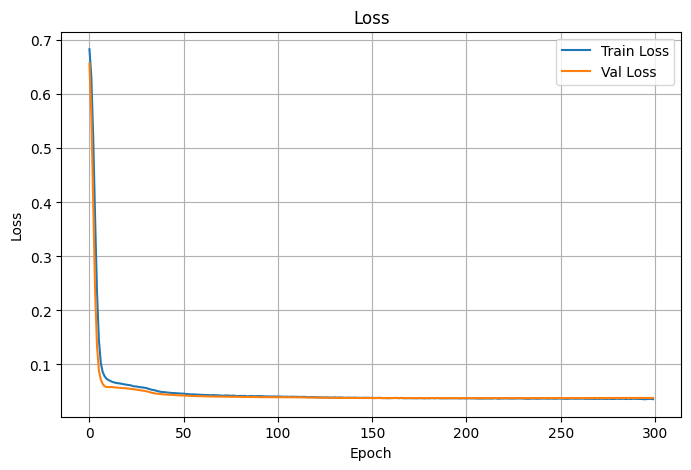

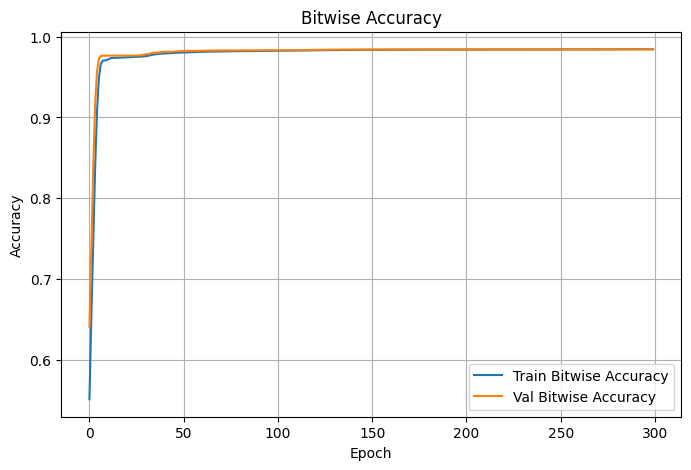

Best Train Bitwise Accuracy: 0.9843650870073595
Best Val Bitwise Accuracy: 0.9841418712887177
Best Train One-Bit Accuracy: 0.8574457814708824
Best Val One-Bit Accuracy: 0.856398733074528
Best Train Zero-Bit Accuracy: 0.9942288612219712
Best Val Zero-Bit Accuracy: 0.9954284935677635
Best Val Bitwise Accuracy: 0.9841418712887177
At Epoch: 230


In [14]:
import matplotlib.pyplot as plt

train_losses = [x["loss"] for x in train_history]
val_losses = [x["loss"] for x in val_history]

train_bit_acc = [x["bitwise_accuracy"] for x in train_history]
val_bit_acc = [x["bitwise_accuracy"] for x in val_history]

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_bit_acc, label="Train Bitwise Accuracy")
plt.plot(val_bit_acc, label="Val Bitwise Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Bitwise Accuracy")
plt.legend()
plt.grid(True)
plt.show()

best_train_bit_acc = max(x["bitwise_accuracy"] for x in train_history)
best_val_bit_acc = max(x["bitwise_accuracy"] for x in val_history)

best_train_one_acc = max(x["one_bit_accuracy"] for x in train_history)
best_val_one_acc = max(x["one_bit_accuracy"] for x in val_history)

best_train_zero_acc = max(x["zero_bit_accuracy"] for x in train_history)
best_val_zero_acc = max(x["zero_bit_accuracy"] for x in val_history)

print("Best Train Bitwise Accuracy:", best_train_bit_acc)
print("Best Val Bitwise Accuracy:", best_val_bit_acc)

print("Best Train One-Bit Accuracy:", best_train_one_acc)
print("Best Val One-Bit Accuracy:", best_val_one_acc)

print("Best Train Zero-Bit Accuracy:", best_train_zero_acc)
print("Best Val Zero-Bit Accuracy:", best_val_zero_acc)

best_val_epoch = max(range(len(val_history)), key=lambda i: val_history[i]["bitwise_accuracy"])

print("Best Val Bitwise Accuracy:", val_history[best_val_epoch]["bitwise_accuracy"])
print("At Epoch:", best_val_epoch + 1)

In [15]:
model.eval()

test_metrics = validate_one_epoch(
    model,
    test_loader,
    criterion,
    device
)

test_loss = test_metrics["loss"]
test_acc = test_metrics["bitwise_accuracy"]

print("Final test loss using best validation model:", test_loss)
print("Final test accuracy using best validation model:", test_acc)

Final test loss using best validation model: 0.03767780214548111
Final test accuracy using best validation model: 0.984240410848981


In [18]:
# ============================================================
# SAVE TRANSFORMER MODEL + TRAINING RESULTS
# Uses train_history and val_history
# ============================================================

import os
import torch
import pandas as pd
import numpy as np

save_dir = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved"
os.makedirs(save_dir, exist_ok=True)
lr = 1e-4
n_epochs = 300
model_path = os.path.join(save_dir, "transformer_model_best_val.pth")
excel_path = os.path.join(save_dir, "transformer_training_results.xlsx")
csv_path = os.path.join(save_dir, "transformer_training_results.csv")
txt_path = os.path.join(save_dir, "transformer_training_summary.txt")

# ------------------------------------------------------------
# Extract histories
# ------------------------------------------------------------
train_losses = [x["loss"] for x in train_history]
val_losses   = [x["loss"] for x in val_history]

train_bit_acc = [x["bitwise_accuracy"] for x in train_history]
val_bit_acc   = [x["bitwise_accuracy"] for x in val_history]

train_one_acc = [x["one_bit_accuracy"] for x in train_history]
val_one_acc   = [x["one_bit_accuracy"] for x in val_history]

train_zero_acc = [x["zero_bit_accuracy"] for x in train_history]
val_zero_acc   = [x["zero_bit_accuracy"] for x in val_history]

# ------------------------------------------------------------
# Find best epoch based on validation bitwise accuracy
# ------------------------------------------------------------
best_epoch_idx = int(np.argmax(val_bit_acc))
best_epoch = best_epoch_idx + 1

best_train_loss = train_losses[best_epoch_idx]
best_val_loss   = val_losses[best_epoch_idx]

best_train_bit_acc = train_bit_acc[best_epoch_idx]
best_val_bit_acc   = val_bit_acc[best_epoch_idx]

best_train_one_acc = train_one_acc[best_epoch_idx]
best_val_one_acc   = val_one_acc[best_epoch_idx]

best_train_zero_acc = train_zero_acc[best_epoch_idx]
best_val_zero_acc   = val_zero_acc[best_epoch_idx]

# ------------------------------------------------------------
# Save model checkpoint
# ------------------------------------------------------------
checkpoint_to_save = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),

    "n_epochs": n_epochs,
    "learning_rate": lr,

    "train_history": train_history,
    "val_history": val_history,

    "train_losses": train_losses,
    "val_losses": val_losses,

    "train_bit_acc": train_bit_acc,
    "val_bit_acc": val_bit_acc,

    "train_one_acc": train_one_acc,
    "val_one_acc": val_one_acc,

    "train_zero_acc": train_zero_acc,
    "val_zero_acc": val_zero_acc,

    "best_epoch": best_epoch,
    "best_train_loss": best_train_loss,
    "best_val_loss": best_val_loss,

    "best_train_bit_acc": best_train_bit_acc,
    "best_val_bit_acc": best_val_bit_acc,

    "best_train_one_acc": best_train_one_acc,
    "best_val_one_acc": best_val_one_acc,

    "best_train_zero_acc": best_train_zero_acc,
    "best_val_zero_acc": best_val_zero_acc,
}

# Add test results only if you already calculated them
if "test_loss" in globals():
    checkpoint_to_save["test_loss"] = test_loss

if "test_acc" in globals():
    checkpoint_to_save["test_acc"] = test_acc

torch.save(checkpoint_to_save, model_path)

# ------------------------------------------------------------
# Save full epoch-by-epoch history
# ------------------------------------------------------------
history_df = pd.DataFrame({
    "epoch": list(range(1, len(train_losses) + 1)),

    "train_loss": train_losses,
    "val_loss": val_losses,

    "train_bitwise_accuracy": train_bit_acc,
    "val_bitwise_accuracy": val_bit_acc,

    "train_one_bit_accuracy": train_one_acc,
    "val_one_bit_accuracy": val_one_acc,

    "train_zero_bit_accuracy": train_zero_acc,
    "val_zero_bit_accuracy": val_zero_acc,
})

history_df["is_best_epoch"] = history_df["epoch"] == best_epoch

if "test_loss" in globals():
    history_df["final_test_loss_using_best_model"] = test_loss

if "test_acc" in globals():
    history_df["final_test_accuracy_using_best_model"] = test_acc

history_df.to_excel(excel_path, index=False)
history_df.to_csv(csv_path, index=False)

# ------------------------------------------------------------
# Save readable summary using BEST model values
# ------------------------------------------------------------
with open(txt_path, "w") as f:
    f.write("Transformer Training Summary\n")
    f.write("============================\n\n")

    f.write(f"Number of epochs trained: {n_epochs}\n")
    f.write(f"Learning rate: {lr}\n\n")

    f.write("Best Validation Model\n")
    f.write("---------------------\n")
    f.write(f"Best epoch: {best_epoch}\n")
    f.write(f"Best model train loss: {best_train_loss:.6f}\n")
    f.write(f"Best model validation loss: {best_val_loss:.6f}\n\n")

    f.write(f"Best model train bitwise accuracy: {best_train_bit_acc:.4f}\n")
    f.write(f"Best model validation bitwise accuracy: {best_val_bit_acc:.4f}\n\n")

    f.write(f"Best model train one-bit accuracy: {best_train_one_acc:.4f}\n")
    f.write(f"Best model validation one-bit accuracy: {best_val_one_acc:.4f}\n\n")

    f.write(f"Best model train zero-bit accuracy: {best_train_zero_acc:.4f}\n")
    f.write(f"Best model validation zero-bit accuracy: {best_val_zero_acc:.4f}\n\n")

    f.write("Final Test Result Using Best Validation Model\n")
    f.write("---------------------------------------------\n")

    if "test_loss" in globals():
        f.write(f"Test loss: {test_loss:.6f}\n")
    else:
        f.write("Test loss: not calculated\n")

    if "test_acc" in globals():
        f.write(f"Test accuracy: {test_acc:.4f}\n")
    else:
        f.write("Test accuracy: not calculated\n")

print("All Transformer files saved:")
print(model_path)
print(excel_path)
print(csv_path)
print(txt_path)

All Transformer files saved:
D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved\transformer_model_best_val.pth
D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved\transformer_training_results.xlsx
D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved\transformer_training_results.csv
D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved\transformer_training_summary.txt


In [34]:
def is_feasible_from_predicted_z(predicted_z, epsilon):
    """
    Check feasibility from predicted binary z values (violation indicators).

    Args:
        predicted_z (np.array): shape (nbScenarios, nbScenarios_chance)
            1 = satisfied (no violation), 0 = violated
        epsilon (float): maximum allowed violation rate
            e.g. epsilon = 0.05 means up to 5% violations allowed

    Returns:
        is_feasible_list (np.array): shape (nbScenarios,)
            1 if feasible, 0 otherwise
        violated_counts (np.array): shape (nbScenarios,)
            number of violations per scenario
        max_violations (int): maximum allowed number of violations
    """
    predicted_z = np.asarray(predicted_z)

    if predicted_z.ndim != 2:
        raise ValueError(f"predicted_z must be 2D, got shape {predicted_z.shape}")

    nbScenarios, nbScenarios_chance = predicted_z.shape

    # Calculate maximum allowed violations
    max_violations = int(epsilon * nbScenarios_chance)

    # Count how many 0s (violations) in each row (scenario)
    violated_counts = np.sum(predicted_z == 0, axis=1).astype(int)

    # Feasible if violations <= max_violations
    is_feasible_list = (violated_counts <= max_violations).astype(int)

    return is_feasible_list, violated_counts, max_violations

In [35]:
import time
def violate_min_up_time_constraint(min_up_time, predicted_OnOff):
    T = 24
    AddTime = 11

    # a = predicted_OnOff[t-1] (previous hour)
    # b = predicted_OnOff[t] (current hour)
    # c = predicted_OnOff[k] (some future hour)

    # t is the possible startup time
    for t in range(1, T - min_up_time + AddTime):
        # k checks the next min_up_time hours after startup
        for k in range(t, min_up_time + t):
            a = predicted_OnOff[t - 1] if t <= 24 else 0
            b = predicted_OnOff[t] if t <= 23 else 0
            if (k >= 24):
                c = 0
            else:
                c = predicted_OnOff[k]
            # At startup time, we said -a + b = 1. a=0, b=1 at start up
            # Now, c is either 0 or 1:
            # If later hour k is ON → c = 1 → 1 - 1 = 0 → not > 0
            # If later hour k is OFF → c = 0 → 1 - 0 = 1 → > 0 → violation
            if (-a + b - c > 0):
                return True
    return False

def violate_min_down_time_constraint(min_down_time, predicted_OnOff):
    T = 24
    AddTime = 11
    for t in range(1, T - min_down_time + AddTime):
        for k in range(t, min_down_time + t):
            a = predicted_OnOff[t - 1] if t <= 24 else 0
            b = predicted_OnOff[t] if t <= 23 else 0
            if (k >= 24):
                c = 0
            else:
                c = predicted_OnOff[k]
            # So a - b is 1 only at shutdown. a=1, b=0 at shut down
            # If later hour k is OFF → c = 0 → 1 + 0 = 1 → not > 1 ✅ (good)
            # If later hour k is ON → c = 1 → 1 + 1 = 2 → > 1 → violation ❌
            if (a - b + c > 1):
                return True
    return False


def is_feasible_V1(predGOn_one, min_up_times, min_down_times, G=54, T=24):
    # predGOn_one: (54,24)
    predGOn_one = np.round(predGOn_one)

    # Creates an array length G filled with 1s:
    # feasibleG[g] = 1 means generator g is feasible
    # feasibleG[g] = 0 means generator g violates at least one constraint
    feasibleG = np.ones((G))
    startTime = time.time()

    for g in range(G):
        # Takes generator g’s predicted schedule predGOn_one[g, :] (length 24).
        # Checks minimum up time constraint using that generator’s min_up_times[g].
        if violate_min_up_time_constraint(min_up_times[g], predGOn_one[g, :]):
            feasibleG[g] = 0;
        if violate_min_down_time_constraint(min_down_times[g], predGOn_one[g, :]):
            feasibleG[g] = 0;

    feasCheckTime = time.time() - startTime
    return feasibleG, feasCheckTime

In [36]:
def violate_singular_arc_constraint(arc_ts):
# Inputs:
#     arc_ts    arc at timespan ts    vector [30]
#
# Outputs:
#     A boolean {True = violation, False = no violation}
# ✅ [0,0,0,1,0,...,0] → sum = 1 → no violation
# ❌ [0,0,0,0,0,...,0] → sum = 0 → violation (chose none)
# ❌ [0,1,0,1,0,...,0] → sum = 2 → violation (chose two)
# At each time step, the ES must pick exactly one arc
    if (arc_ts.sum() != 1):
        return True
    return False


def violate_initial_TES_state_constraint(arc_ts_0):
# Inputs:
#     arc_ts_0    arc at timespan 0    vector [30]
#
# Outputs:
#     A boolean {True = violation, False = no violation}

    # arc_ts_0[0] + arc_ts_0[1] + arc_ts_0[2] must equal 1
    # exactly one of those three must be 1
    # and (implicitly) the ES must not choose any other arc as the initial one 
    # (because if the “one” is somewhere else, these three sum to 0 → violation)
    if (arc_ts_0[0] + arc_ts_0[1] + arc_ts_0[2] != 1):
        return True
    return False

def violate_terminal_TES_state_constraint(arc_ts_23):
# Inputs:
#     arc_ts_23    arc at timespan 23    vector [30]
#
# Outputs:
#     A boolean {True = violation, False = no violation}
    # if (arc_ts_23[3] + arc_ts_23[7] + arc_ts_23[22] != 1):

    # Among indices 9, 19, 29, the sum must be exactly 1
    # → exactly one of those three must be 1 at the last time step.
    # Among indices 9, 19, 29, the sum must be exactly 1
    # → exactly one of those three must be 1 at the last time step.
    if (arc_ts_23[9] + arc_ts_23[19] + arc_ts_23[29] != 1):
        return True
    return False

def violate_TES_state_transition_constraint(arc_ts, arc_next_ts):
# Inputs:
#     arc_ts        arc at timespan ts      vector [9]
#     arc_next_ts   arc at timespan ts+1    vector [9]
#
# Outputs:
#     A boolean {True = violation, False = no violation}
# The ES state at time ts (computed as a sum of some arc entries) must equal the ES state at time ts+1 (computed as a sum of some other arc entries).
    if (arc_ts[0] + arc_ts[15] + arc_ts[24] != arc_next_ts[0] + arc_next_ts[1] + arc_next_ts[2]):
        return True
    if (arc_ts[3] + arc_ts[7] + arc_ts[22] != arc_next_ts[3] + arc_next_ts[4] + arc_next_ts[5]):
        return True
    if (arc_ts[6] + arc_ts[5] + arc_ts[27] != arc_next_ts[6] + arc_next_ts[7] + arc_next_ts[8]):
        return True
    if (arc_ts[9] + arc_ts[19] + arc_ts[29] != arc_next_ts[9] + arc_next_ts[10] + arc_next_ts[11]):
        return True
    if (arc_ts[12] + arc_ts[1] + arc_ts[17] + arc_ts[21] != arc_next_ts[12] + arc_next_ts[13] + arc_next_ts[14] + arc_next_ts[15]):
        return True
    if (arc_ts[16] + arc_ts[11] + arc_ts[14] + arc_ts[28] != arc_next_ts[16] + arc_next_ts[17] + arc_next_ts[18] + arc_next_ts[19]):
        return True
    if (arc_ts[20] + arc_ts[2] + arc_ts[4] + arc_ts[13] + arc_ts[26] != arc_next_ts[20] + arc_next_ts[21] + arc_next_ts[22] + arc_next_ts[23] + arc_next_ts[24]):
        return True
    if (arc_ts[25] + arc_ts[8] + arc_ts[10] + arc_ts[18] + arc_ts[23] != arc_next_ts[25] + arc_next_ts[26] + arc_next_ts[27] + arc_next_ts[28] + arc_next_ts[29]):
        return True
    return False

def violate_charge_transfer_while_moving_constraint(feasible_arc_ts, ESCOnOff_ts, ESDOnOff_ts):
# Inputs:
#     feasible_arc_ts        arc at timespan ts      vector [30]
#     ESCOnOff_ts            charging status of ES at timespan ts [BINARY]
#     ESDOnOff_ts            discharging status of ES at timespan ts [BINARY]
# Outputs:
#     A boolean {True = violation, False = no violation}

    # In this model, that subset corresponds to “staying at a station” (not moving).
    # So if the ES is not moving, exactly one of these “stay” arcs should be active (sum = 1).
    # If the ES is moving, then none of these “stay” arcs are active (sum = 0)

    # Moving: is_staying = 0
    # If charging or discharging happens (sum=1), then 0 < 1 → violation ✅
    # Staying: is_staying = 1
    # If charging or discharging happens (sum=1), 1 < 1 false → no violation ✅
    # If no charge/discharge (sum=0), 1 < 0 false → no violation ✅
    # If both charge and discharge = 1 (sum=2), even staying gives 1 < 2 → violation ✅

    if (feasible_arc_ts[0] + feasible_arc_ts[3] + feasible_arc_ts[6] + feasible_arc_ts[9] + feasible_arc_ts[12] + feasible_arc_ts[16] + feasible_arc_ts[20] + feasible_arc_ts[25] < ESCOnOff_ts + ESDOnOff_ts):
        return True
    return False

def is_feasible_V2(predictedArc, predictedESCOnOff, predictedESDOnOff,
                   nbes_active, TS=24, arc_A=30):
    """
    predictedArc:       (max_es, TS, 30)
    predictedESCOnOff:  (max_es, TS)
    predictedESDOnOff:  (max_es, TS)
    nbes_active: int in [0..max_es]
    """

    predictedArc      = np.round(predictedArc)
    predictedESCOnOff = np.round(predictedESCOnOff)
    predictedESDOnOff = np.round(predictedESDOnOff)

    # K = number of ES that are active for this scenario.
    K = int(nbes_active)

    if K <= 0:
        arc_is_feasible = np.array([], dtype=bool)
        feasible_arc_TS = np.zeros((TS, 0))
        feasible_ESC_TS = np.zeros((TS, 0))
        feasible_ESD_TS = np.zeros((TS, 0))
        return arc_is_feasible, feasible_arc_TS, feasible_ESC_TS, feasible_ESD_TS, 0.0

    # Slices to only the first K ES units.
    # So now:
    # arc shape is (K, TS, 30)
    # esc shape is (K, TS)
    # esd shape is (K, TS)

    arc = predictedArc[:K]
    esc = predictedESCOnOff[:K]
    esd = predictedESDOnOff[:K]

    arc_is_feasible = np.ones((K,), dtype=bool)
    feasible_arc_TS = np.ones((TS, K))
    feasible_ESC_TS = np.ones((TS, K))
    feasible_ESD_TS = np.ones((TS, K))

    startTime = time.time()

    # Loop through each ES unit: k = 0..K-1
    for k in range(K):
        for ts in range(TS):
            # For each time step ts:
            # arc[k, ts, :] is a vector of length 30 
            if violate_singular_arc_constraint(arc[k, ts, :]):
                arc_is_feasible[k] = False
                feasible_arc_TS[ts, k] = 0

        # Checks arc choice at ts=0 must belong to allowed initial arcs (like 0/1/2).
        if violate_initial_TES_state_constraint(arc[k, 0, :]):
            arc_is_feasible[k] = False
            feasible_arc_TS[0, k] = 0

        # Checks whether the chosen arc at time ts correctly transitions to the next time ts+1.
        if violate_terminal_TES_state_constraint(arc[k, -1, :]):
            arc_is_feasible[k] = False
            feasible_arc_TS[-1, k] = 0

        # Checks whether the chosen arc at time ts correctly transitions to the next time ts+1.
        for ts in range(TS - 1):
            if violate_TES_state_transition_constraint(arc[k, ts, :], arc[k, ts + 1, :]):
                arc_is_feasible[k] = False
                feasible_arc_TS[ts, k] = 0
                feasible_arc_TS[ts + 1, k] = 0

        # the arc vector (30), ESC on/off at this ts, ESD on/off at this ts
        # That function returns True if charge/discharge happens when “moving”.
        for ts in range(TS):
            if feasible_arc_TS[ts, k] == 1:
                if violate_charge_transfer_while_moving_constraint(
                    arc[k, ts, :], esc[k, ts], esd[k, ts]
                ):
                    feasible_arc_TS[ts, k] = 0
                    feasible_ESC_TS[ts, k] = 0
                    feasible_ESD_TS[ts, k] = 0
            else:
                feasible_ESC_TS[ts, k] = 0
                feasible_ESD_TS[ts, k] = 0

    feasCheckTime = time.time() - startTime
    return arc_is_feasible, feasible_arc_TS, feasible_ESC_TS, feasible_ESD_TS, feasCheckTime

In [37]:
def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def predict_transformer(model, X_test_seq, device, batch_size=64, threshold=0.5):
    """
    X_test_seq shape: (S, 24, token_dim)

    Returns:
        predGOn:  (S, 54, 24)
        predCC:   (S, 100)
        predESC:  (S, 9, 24)
        predESD:  (S, 9, 24)
        predARC:  (S, 9, 24, 30)
        predTimes:(S,)
    """

    model.eval()

    X_test_tensor = torch.FloatTensor(X_test_seq)
    test_dataset = TensorDataset(X_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_times = []

    with torch.no_grad():
        for batch in test_loader:
            x = batch[0].to(device)

            start = time.time()

            out = model(x)

            # If model output is logits, convert to probabilities.
            # If output is already sigmoid probabilities, this will leave it alone.
            if out.min() < 0 or out.max() > 1:
                out = torch.sigmoid(out)

            yhat = (out >= threshold).float()

            end = time.time()

            batch_time = end - start
            per_sample_time = batch_time / x.shape[0]

            all_preds.append(yhat.cpu().numpy())
            all_times.extend([per_sample_time] * x.shape[0])

    yhat = np.vstack(all_preds)
    predTimes = np.array(all_times)

    # -------------------------
    # Parse flat output vector
    # -------------------------
    n_gen = 54
    T = 24
    n_cc = 100
    max_es = 9
    es_T = 24
    arc_A = 30

    gen_len = n_gen * T          # 1296
    cc_len = n_cc                # 100
    esc_len = es_T               # 24
    esd_len = es_T               # 24
    arc_len = es_T * arc_A       # 720

    total_needed = gen_len + cc_len + max_es * (esc_len + esd_len + arc_len)
    # 1296 + 100 + 9 * (24 + 24 + 720) = 8308

    if yhat.shape[1] < total_needed:
        raise ValueError(
            f"Transformer output_dim={yhat.shape[1]} but need {total_needed}. "
            "Check your final output layer."
        )

    S = yhat.shape[0]

    predGOn = np.zeros((S, n_gen, T))
    predCC  = np.zeros((S, n_cc))
    predESC = np.zeros((S, max_es, es_T))
    predESD = np.zeros((S, max_es, es_T))
    predARC = np.zeros((S, max_es, es_T, arc_A))

    for s in range(S):
        k = 0

        predGOn[s] = yhat[s, k:k + gen_len].reshape(n_gen, T)
        k += gen_len

        predCC[s] = yhat[s, k:k + cc_len]
        k += cc_len

        for es in range(max_es):
            predESC[s, es] = yhat[s, k:k + esc_len]
            k += esc_len

            predESD[s, es] = yhat[s, k:k + esd_len]
            k += esd_len

            predARC[s, es] = yhat[s, k:k + arc_len].reshape(es_T, arc_A)
            k += arc_len

        if k != total_needed:
            raise ValueError(f"Parsing ended at k={k}, expected {total_needed}.")

    return predGOn, predCC, predESC, predESD, predARC, predTimes

In [38]:
# Put your trained Transformer model here
# Example:
from prettytable import PrettyTable
transformer_model = model
# or
# transformer_model = transformer

transformer_model.eval()

# Predict on the final test set
predGOn, predCC, predESC, predESD, predARC, predictionTimes = predict_transformer(
    model=transformer_model,
    X_test_seq=X_test_seq,
    device=device,
    batch_size=64,
    threshold=0.5
)

def count_parameters(model):
    # Creates a pretty table with 2 columns: the parameter name (“Modules”) and how many numbers it contains (“Parameters”).
    table = PrettyTable(["Modules", "Parameters"])
    total_params = 0

    # Loops through every parameter tensor in the model. name is a string like "conv1.weight", "fc.bias", etc. parameter is the actual tensor (weights/biases).
    for name, parameter in model.named_parameters():
        # Skips parameters that are frozen (not trainable).requires_grad=False means they won’t be updated by backprop.
        if not parameter.requires_grad: continue

        #  Counts how many scalar values are in that tensor. Example: a weight tensor of shape (64, 32, 3, 3) has 64*32*3*3 numbers.
        params = parameter.numel()

        # Adds a row to the table showing the parameter name and its count.
        table.add_row([name, params])
        total_params+=params
    print(table)
    print(f"Total Trainable Params: {total_params}")

In [91]:
relevant_confidence = X_test_raw[:, 0]   # Confidence_Level
nbes_list = X_test_raw[:, 1]             # nbES

# If confidence is saved as 60,70,80,90,95 convert to 0.60,0.70,...
if relevant_confidence.max() > 1:
    relevant_confidence = relevant_confidence / 100.0

nbes_list = np.round(nbes_list).astype(int)
confidence_levels_list = relevant_confidence.reshape(-1)

print("nbes_list shape:", nbes_list.shape)
print("confidence_levels_list shape:", confidence_levels_list.shape)
print("Unique nbES:", np.unique(nbes_list))
print("Unique confidence:", np.unique(confidence_levels_list))

nbes_list shape: (375,)
confidence_levels_list shape: (375,)
Unique nbES: [1 3 5 7 9]
Unique confidence: [0.6  0.7  0.8  0.9  0.95]


In [92]:
# -----------------------
# 1) Setup
# -----------------------
S = predGOn.shape[0]

print("Prediction shapes:")
print("predGOn:", predGOn.shape)   # (S, 54, 24)
print("predCC: ", predCC.shape)    # (S, 100)
print("predESC:", predESC.shape)   # (S, 9, 24)
print("predESD:", predESD.shape)   # (S, 9, 24)
print("predARC:", predARC.shape)   # (S, 9, 24, 30)


# -----------------------
# 2) Generator On/Off feasibility
# -----------------------
min_up_times = np.array([
    1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
    5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
    5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
])

min_down_times = np.array([
    1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
    5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
    5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
])

feasibleG = np.zeros((S, 54))
feasCheckTimes_V1 = np.zeros((S, 1))

for i in range(S):
    feasibleG[i, :], feasCheckTimes_V1[i, 0] = is_feasible_V1(
        predGOn[i],
        min_up_times,
        min_down_times,
        G=54,
        T=24
    )


# -----------------------
# 3) Arc / ESC / ESD feasibility
# -----------------------
TS = 24
max_es = 9

arc_is_feasible_pad = np.zeros((S, max_es))
feasible_arc_TS_pad = np.zeros((S, TS, max_es))
feasible_ESC_TS_pad = np.zeros((S, TS, max_es))
feasible_ESD_TS_pad = np.zeros((S, TS, max_es))
feasCheckTimes_V2 = np.zeros((S, 1))

nbes_list = np.asarray(nbes_list).reshape(-1).astype(int)
confidence_levels_list = np.asarray(relevant_confidence).reshape(-1)

feasible_CC = np.zeros((S, 1), dtype=int)
violated_counts_CC = np.zeros((S, 1), dtype=int)
max_violations_CC = np.zeros((S, 1), dtype=int)

for i in range(S):

    nbes_active = int(round(nbes_list[i]))
    nbes_active = max(0, min(max_es, nbes_active))
    nbes_list[i] = nbes_active

    arc_is_feasible, f_arc, f_esc, f_esd, t2 = is_feasible_V2(
        predictedArc=predARC[i],
        predictedESCOnOff=predESC[i],
        predictedESDOnOff=predESD[i],
        nbes_active=nbes_active,
        TS=TS,
        arc_A=30
    )

    feasCheckTimes_V2[i, 0] = t2

    if nbes_active > 0:
        arc_is_feasible_pad[i, :nbes_active] = arc_is_feasible.astype(float)
        feasible_arc_TS_pad[i, :, :nbes_active] = f_arc
        feasible_ESC_TS_pad[i, :, :nbes_active] = f_esc
        feasible_ESD_TS_pad[i, :, :nbes_active] = f_esd


# -----------------------
# 4) Chance constraint feasibility
# -----------------------
num_feasible_chance_constraints = 0
fully_feasible_scenarios = []

for i in range(S):
    confidence_level = float(confidence_levels_list[i])

    epsilon = 1.0 - confidence_level

    cc_row = predCC[i].reshape(1, -1)

    feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(
        cc_row,
        epsilon
    )

    feasible_CC[i, 0] = feasible_i[0]
    violated_counts_CC[i, 0] = violated_i[0]
    max_violations_CC[i, 0] = max_viol_i

    if feasible_i[0] == 1:
        num_feasible_chance_constraints += 1
        fully_feasible_scenarios.append(i)


# -----------------------
# 5) Metrics
# -----------------------
feasCheckTimes = feasCheckTimes_V1 + feasCheckTimes_V2

total_active_es = int(nbes_list.sum())
total_ts_checks = int((nbes_list * TS).sum())

feasible_es_count = 0
feasible_ts_count = 0
feasible_esc_count = 0
feasible_esd_count = 0
fully_feasible_es_scenarios = 0

for i in range(S):
    K = nbes_list[i]

    if K == 0:
        fully_feasible_es_scenarios += 1
        continue

    feasible_es_count += int(arc_is_feasible_pad[i, :K].sum())
    feasible_ts_count += int(feasible_arc_TS_pad[i, :, :K].sum())
    feasible_esc_count += int(feasible_ESC_TS_pad[i, :, :K].sum())
    feasible_esd_count += int(feasible_ESD_TS_pad[i, :, :K].sum())

    if np.all(arc_is_feasible_pad[i, :K] == 1):
        fully_feasible_es_scenarios += 1


# -----------------------
# 6) Print results
# -----------------------
print(f'{transformer_model.__class__.__name__}')


# Use this only if your count_parameters function works for Transformer too
count_parameters(transformer_model)

print('----------------------------------------------------------------------------------')
print(f' Number of generators with feasible OnOffs throughout all 24 hours:   {feasibleG.sum()}')
print(f'                                        Total number of generators:   {(S * 54)}')
print(f' Over all scenarios, average number of feasible generators OnOffs:    {feasibleG.sum() / S:.4f} / 54')
print(f'       Scenario with maximum number of feasible generators OnOffs:    {feasibleG.sum(1).max()}')
print(f'       Scenario with minimum number of feasible generators OnOffs:    {feasibleG.sum(1).min()}')
print('----------------------------------------------------------------------------------')
print(f'               Number of scenarios with fully feasible 54 OnOffs:     {(feasibleG.sum(1) == 54).sum()}')
print(f'                                         Total number of scenarios:   {S}')
print('----------------------------------------------------------------------------------')
print(f'  Total ACTIVE ES across all scenarios:                    {total_active_es}')
print(f'  Number of feasible TS ACTIVE only:                       {feasible_ts_count}')
print(f'  Total number of TS ACTIVE only:                          {total_ts_checks}')
print(f'  Average number of feasible TS per scenario:              {feasible_ts_count / S:.4f}')
print('----------------------------------------------------------------------------------')
print(f'  Number of feasible ES ACTIVE only:                       {feasible_es_count}')
print(f'  Total number of ES ACTIVE only:                          {total_active_es}')
print(f'  Scenarios where ALL active ES are feasible:              {fully_feasible_es_scenarios} / {S}')
print('----------------------------------------------------------------------------------')
print(f'  Number of feasible ESCOnOff ACTIVE only:                 {feasible_esc_count}')
print(f'  Total number of ESCOnOff ACTIVE only:                    {total_ts_checks}')
print('----------------------------------------------------------------------------------')
print(f'  Number of feasible ESDOnOff ACTIVE only:                 {feasible_esd_count}')
print(f'  Total number of ESDOnOff ACTIVE only:                    {total_ts_checks}')
print('----------------------------------------------------------------------------------')
print(f'  Number of feasible Chance Constraints:                   {num_feasible_chance_constraints}')
print(f'  Scenarios with feasible Chance Constraints:              {fully_feasible_scenarios}')
print('----------------------------------------------------------------------------------')
print(f'Average Prediction Time for 1 scenario = {np.average(predictionTimes):.6f} s')
print('----------------------------------------------------------------------------------')
print(f'Average Feasibility Check Time for 1 scenario = {np.average(feasCheckTimes):.6f} s')
print('----------------------------------------------------------------------------------')

Prediction shapes:
predGOn: (375, 54, 24)
predCC:  (375, 100)
predESC: (375, 9, 24)
predESD: (375, 9, 24)
predARC: (375, 9, 24, 30)
Transformer
+--------------------------------------------------------+------------+
|                        Modules                         | Parameters |
+--------------------------------------------------------+------------+
|                    embedding.weight                    |   25856    |
|                     embedding.bias                     |    128     |
| transformer_encoder.layers.0.self_attn.in_proj_weight  |   49152    |
|  transformer_encoder.layers.0.self_attn.in_proj_bias   |    384     |
| transformer_encoder.layers.0.self_attn.out_proj.weight |   16384    |
|  transformer_encoder.layers.0.self_attn.out_proj.bias  |    128     |
|      transformer_encoder.layers.0.linear1.weight       |   131072   |
|       transformer_encoder.layers.0.linear1.bias        |    1024    |
|      transformer_encoder.layers.0.linear2.weight       |   131

In [39]:
# ============================================================
# TRANSFORMER EXTERNAL TEST PREDICTION
# ACCURACY / PRECISION / RECALL / F1
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 1) LOAD SAVED TRANSFORMER MODEL
# ============================================================

# Make sure this model architecture is already defined exactly like training
model = model.to(device)

model_path = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved\transformer_model_best_val.pth"

checkpoint = torch.load(model_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Transformer model loaded successfully")

if "best_epoch" in checkpoint:
    print("Best epoch:", checkpoint["best_epoch"])
if "best_val_loss" in checkpoint:
    print("Best validation loss:", checkpoint["best_val_loss"])
if "best_val_acc" in checkpoint:
    print("Best validation accuracy:", checkpoint["best_val_acc"])


# ============================================================
# 2) CHECK SCALER EXISTS
# ============================================================

try:
    scaler
    print("Scaler found.")
except NameError:
    raise NameError(
        "scaler is not defined. You need the same StandardScaler fitted on the Transformer training data."
    )


# ============================================================
# 3) BUILD HOUR FEATURE INDICES
# ============================================================

def build_hour_feature_indices(feature_columns):
    """
    Builds hour token index order:
    [Confidence_Level, nbES, Solar_sc0..sc99 at hour t, Wind_sc0..sc99 at hour t]
    """

    if "Confidence_Level" not in feature_columns:
        raise KeyError("Confidence_Level not found in feature columns")

    if "nbES" not in feature_columns:
        raise KeyError("nbES not found in feature columns")

    conf_idx = feature_columns.index("Confidence_Level")
    nbes_idx = feature_columns.index("nbES")

    solar_pattern = re.compile(r"^Solar_sc(\d+)_t(\d+)$")
    wind_pattern  = re.compile(r"^Wind_sc(\d+)_t(\d+)$")

    solar_map = {}
    wind_map = {}

    for idx, col in enumerate(feature_columns):
        m_solar = solar_pattern.match(col)
        m_wind = wind_pattern.match(col)

        if m_solar:
            sc = int(m_solar.group(1))
            hr = int(m_solar.group(2))
            solar_map[(sc, hr)] = idx

        if m_wind:
            sc = int(m_wind.group(1))
            hr = int(m_wind.group(2))
            wind_map[(sc, hr)] = idx

    if len(solar_map) == 0:
        raise ValueError("No solar columns found. Check Solar_sc*_t* naming.")

    if len(wind_map) == 0:
        raise ValueError("No wind columns found. Check Wind_sc*_t* naming.")

    solar_scenarios = sorted({sc for sc, hr in solar_map.keys()})
    wind_scenarios = sorted({sc for sc, hr in wind_map.keys()})

    solar_hours = sorted({hr for sc, hr in solar_map.keys()})
    wind_hours = sorted({hr for sc, hr in wind_map.keys()})

    if solar_hours != list(range(24)):
        raise ValueError(f"Expected solar hours 0..23, got {solar_hours}")

    if wind_hours != list(range(24)):
        raise ValueError(f"Expected wind hours 0..23, got {wind_hours}")

    if solar_scenarios != wind_scenarios:
        raise ValueError("Solar and wind scenario indices do not match")

    if len(solar_scenarios) != 100:
        raise ValueError(f"Expected 100 scenarios, got {len(solar_scenarios)}")

    hour_feature_indices = []

    for t in range(24):
        one_hour_indices = []

        one_hour_indices.append(conf_idx)
        one_hour_indices.append(nbes_idx)

        for sc in solar_scenarios:
            one_hour_indices.append(solar_map[(sc, t)])

        for sc in wind_scenarios:
            one_hour_indices.append(wind_map[(sc, t)])

        hour_feature_indices.append(one_hour_indices)

    hour_feature_indices = np.array(hour_feature_indices, dtype=np.int64)

    return hour_feature_indices


def reshape_flat_features_to_hour_tokens(X_flat, hour_feature_indices):
    """
    X_flat: shape (N, num_features)
    hour_feature_indices: shape (24, token_dim)

    Returns:
        X_seq: shape (N, 24, token_dim)
    """

    N = X_flat.shape[0]
    seq_len, token_dim = hour_feature_indices.shape

    X_seq = np.zeros((N, seq_len, token_dim), dtype=np.float32)

    for t in range(seq_len):
        X_seq[:, t, :] = X_flat[:, hour_feature_indices[t]]

    return X_seq


# ============================================================
# 4) LOAD EXTERNAL TEST FILE INTO TRANSFORMER FORMAT
# ============================================================

class ExternalTransformerTestSet:
    def __init__(self, features_path, labels_path, scaler):

        # -------------------------
        # Load raw features
        # -------------------------
        F_df = pd.read_csv(features_path)

        if "Confidence_Level" not in F_df.columns:
            raise KeyError("Confidence_Level column missing in features file")

        if "nbES" not in F_df.columns:
            raise KeyError("nbES column missing in features file")

        self.conf = F_df["Confidence_Level"].to_numpy(dtype=np.float32)
        self.nbes = F_df["nbES"].to_numpy(dtype=np.float32)

        # Convert metadata confidence to 0.60, 0.70, ..., 0.95 if needed
        if self.conf.max() > 1:
            self.conf = self.conf / 100.0

        X_raw = F_df.to_numpy(dtype=np.float32)
        N = X_raw.shape[0]

        # Build hour token indices from the external file columns
        feature_columns = list(F_df.columns)
        hour_feature_indices = build_hour_feature_indices(feature_columns)

        # Scale using Transformer training scaler
        X_scaled = scaler.transform(X_raw).astype(np.float32)

        # Reshape into Transformer input: (N, 24, token_dim)
        X_seq = reshape_flat_features_to_hour_tokens(X_scaled, hour_feature_indices)

        self.features = torch.FloatTensor(X_seq)

        # -------------------------
        # Load labels
        # -------------------------
        L_df = pd.read_csv(labels_path)

        if {"Confidence_Level", "nbES"}.issubset(L_df.columns):
            L_df = L_df.drop(columns=["Confidence_Level", "nbES"])
        elif L_df.shape[1] == 8310:
            L_df = L_df.iloc[:, 2:]
        elif L_df.shape[1] == 8308:
            pass
        else:
            raise ValueError(f"Unexpected label column count: {L_df.shape[1]}")

        L = L_df.to_numpy(dtype=np.float32)

        if L.shape[0] != N:
            raise ValueError(f"Feature rows={N}, label rows={L.shape[0]} do not match")

        if L.shape[1] != 8308:
            raise ValueError(f"Expected 8308 label columns, got {L.shape[1]}")

        self.labels = torch.FloatTensor(L)

        self.nbes = np.round(self.nbes).astype(int)

    def __len__(self):
        return self.features.shape[0]


# ============================================================
# 5) TRANSFORMER PREDICT FLAT OUTPUT
# ============================================================

def predict_transformer_flat(model, X_seq, device, batch_size=64, threshold=0.5):
    """
    X_seq: shape (N, 24, token_dim)

    Returns:
        Y_pred: shape (N, 8308)
    """

    model.eval()

    if not torch.is_tensor(X_seq):
        X_seq = torch.FloatTensor(X_seq)

    N = X_seq.shape[0]
    preds = []

    with torch.no_grad():
        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)

            x_batch = X_seq[start:end].to(device)

            out = model(x_batch)

            # If output is logits, convert to probabilities.
            # If output is already sigmoid probabilities, this leaves it alone.
            if out.min() < 0 or out.max() > 1:
                out = torch.sigmoid(out)

            yhat = (out >= threshold).float()
            preds.append(yhat.cpu().numpy())

    Y_pred = np.vstack(preds).astype(int)

    if Y_pred.shape[1] != 8308:
        raise ValueError(f"Expected prediction size 8308, got {Y_pred.shape[1]}")

    return Y_pred


# ============================================================
# 6) METRICS
# ============================================================

def calculate_metrics(Y_true, Y_pred):
    y_true_flat = Y_true.reshape(-1)
    y_pred_flat = Y_pred.reshape(-1)

    return {
        "accuracy": accuracy_score(y_true_flat, y_pred_flat),
        "precision": precision_score(y_true_flat, y_pred_flat, zero_division=0),
        "recall": recall_score(y_true_flat, y_pred_flat, zero_division=0),
        "f1": f1_score(y_true_flat, y_pred_flat, zero_division=0),
        "exact_match_accuracy": np.mean(np.all(Y_true == Y_pred, axis=1))
    }


# ============================================================
# 7) EVALUATE ONE EXTERNAL TRANSFORMER TEST FILE
# ============================================================

def evaluate_transformer_external_file(features_path, labels_path, confidence_name):

    external_testset = ExternalTransformerTestSet(
        features_path=features_path,
        labels_path=labels_path,
        scaler=scaler
    )

    print("\n====================================================")
    print(f"Evaluating Transformer external test file: {confidence_name}")
    print("====================================================")
    print("Features shape:", external_testset.features.shape)
    print("Labels shape:", external_testset.labels.shape)
    print("Unique nbES:", np.unique(external_testset.nbes))
    print("Unique confidence:", np.unique(external_testset.conf))

    Y_pred = predict_transformer_flat(
        model=model,
        X_seq=external_testset.features,
        device=device,
        batch_size=64,
        threshold=0.5
    )

    Y_true = external_testset.labels

    if hasattr(Y_true, "detach"):
        Y_true = Y_true.detach().cpu().numpy()

    Y_true = np.round(Y_true).astype(int)

    print("Y_true shape:", Y_true.shape)
    print("Y_pred shape:", Y_pred.shape)

    nbes_vals = external_testset.nbes
    conf_vals = external_testset.conf

    results = []

    # Overall for this confidence file
    overall_metrics = calculate_metrics(Y_true, Y_pred)

    results.append({
        "model": "Transformer",
        "confidence_file": confidence_name,
        "confidence": float(np.unique(conf_vals)[0]) if len(np.unique(conf_vals)) == 1 else "MIXED",
        "nbES": "ALL",
        "num_samples": len(Y_true),
        **overall_metrics
    })

    # By nbES
    for nbes in sorted(np.unique(nbes_vals)):
        mask = nbes_vals == nbes

        group_metrics = calculate_metrics(Y_true[mask], Y_pred[mask])

        results.append({
            "model": "Transformer",
            "confidence_file": confidence_name,
            "confidence": float(np.unique(conf_vals)[0]) if len(np.unique(conf_vals)) == 1 else "MIXED",
            "nbES": int(nbes),
            "num_samples": int(mask.sum()),
            **group_metrics
        })

    return pd.DataFrame(results), Y_true, Y_pred, nbes_vals, conf_vals


# ============================================================
# 8) EXTERNAL TEST FILE PATHS
# ============================================================

test_files = {
    "CC_60": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_60_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_60_test\Labels_CC.csv",
    },
    "CC_70": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_70_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_70_test\Labels_CC.csv",
    },
    "CC_80": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_80_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_80_test\Labels_CC.csv",
    },
    "CC_90": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_90_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_90_test\Labels_CC.csv",
    },
    "CC_95": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_95_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_95_test\Labels_CC.csv",
    },
}


# ============================================================
# 9) RUN ALL FILES + TRUE OVERALL METRICS
# ============================================================

all_results = []

all_Y_true = []
all_Y_pred = []
all_nbes_vals = []
all_conf_vals = []

for confidence_name, paths in test_files.items():

    results_df_one, Y_true_one, Y_pred_one, nbes_one, conf_one = evaluate_transformer_external_file(
        features_path=paths["features"],
        labels_path=paths["labels"],
        confidence_name=confidence_name
    )

    all_results.append(results_df_one)

    all_Y_true.append(Y_true_one)
    all_Y_pred.append(Y_pred_one)
    all_nbes_vals.append(nbes_one)
    all_conf_vals.append(conf_one)


# Combine all confidence levels together
Y_true_all = np.vstack(all_Y_true)
Y_pred_all = np.vstack(all_Y_pred)

nbes_all = np.concatenate(all_nbes_vals)
conf_all = np.concatenate(all_conf_vals)

print("\nCombined data:")
print("Combined Y_true shape:", Y_true_all.shape)
print("Combined Y_pred shape:", Y_pred_all.shape)
print("Unique confidence:", np.unique(conf_all))
print("Unique nbES:", np.unique(nbes_all))


# True overall metrics across all confidence levels and all nbES
overall_all_metrics = calculate_metrics(Y_true_all, Y_pred_all)

overall_all_row = {
    "model": "Transformer",
    "confidence_file": "ALL",
    "confidence": "ALL",
    "nbES": "ALL",
    "num_samples": len(Y_true_all),
    **overall_all_metrics
}


# Combine detailed results
results_df = pd.concat(all_results, ignore_index=True)

# Add true overall row at top
results_df = pd.concat(
    [pd.DataFrame([overall_all_row]), results_df],
    ignore_index=True
)

print("\nFinal Transformer external test results:")
display(results_df)


# # ============================================================
# # 10) SAVE RESULTS
# # ============================================================

# save_dir = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\external_test_metrics"
# os.makedirs(save_dir, exist_ok=True)

# excel_path = os.path.join(save_dir, "transformer_external_test_accuracy_precision_recall.xlsx")
# csv_path = os.path.join(save_dir, "transformer_external_test_accuracy_precision_recall.csv")

# results_df.to_excel(excel_path, index=False)
# results_df.to_csv(csv_path, index=False)

# print("\nSaved Transformer external test metrics:")
# print(excel_path)
# print(csv_path)

C:\Users\PC\AppData\Local\Temp\ipykernel_26080\1870949634.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Transformer model loaded successfully
Best epoch: 230
Best validation loss: 0.03778897598385811
Scaler found.

Evaluating Transformer external test file: CC_60
Features shape: torch.Size([180, 24, 202])
Labels shape: torch.Size([180, 8308])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.6]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)

Evaluating Transformer external test file: CC_70
Features shape: torch.Size([180, 24, 202])
Labels shape: torch.Size([180, 8308])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.7]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)

Evaluating Transformer external test file: CC_80
Features shape: torch.Size([180, 24, 202])
Labels shape: torch.Size([180, 8308])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.8]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)

Evaluating Transformer external test file: CC_90
Features shape: torch.Size([180, 24, 202])
Labels shape: torch.Size([180, 8308])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Uni

,model,confidence_file,confidence,nbES,num_samples,accuracy,precision,recall,f1,exact_match_accuracy
0,Transformer,ALL,ALL,ALL,900,0.983149,0.919344,0.838716,0.877181,0.0
1,Transformer,CC_60,0.6,ALL,180,0.982822,0.914635,0.830901,0.870760,0.0
2,Transformer,CC_60,0.6,1,20,0.996907,0.972497,0.968485,0.970487,0.0
3,Transformer,CC_60,0.6,2,20,0.988054,0.939727,0.847293,0.891120,0.0
4,Transformer,CC_60,0.6,3,20,0.990413,0.939626,0.900079,0.919427,0.0
5,Transformer,CC_60,0.6,4,20,0.985682,0.930482,0.840769,0.883354,0.0
6,Transformer,CC_60,0.6,5,20,0.985382,0.924560,0.859778,0.890993,0.0
7,Transformer,CC_60,0.6,6,20,0.979255,0.910839,0.796538,0.849863,0.0
8,Transformer,CC_60,0.6,7,20,0.976709,0.893921,0.801381,0.845126,0.0
9,Transformer,CC_60,0.6,8,20,0.972075,0.876081,0.764658,0.816586,0.0


In [20]:
# ============================================================
# 8) EXTERNAL TEST FILE PATHS
# ============================================================

test_files = {
    "CC_60": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_60_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_60_test\Labels_CC.csv",
    },
    "CC_70": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_70_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_70_test\Labels_CC.csv",
    },
    "CC_80": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_80_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_80_test\Labels_CC.csv",
    },
    "CC_90": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_90_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_90_test\Labels_CC.csv",
    },
    "CC_95": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_95_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_95_test\Labels_CC.csv",
    },
}


# ============================================================
# 9) RUN ALL FILES + TRUE OVERALL METRICS
# ============================================================

all_results = []

all_Y_true = []
all_Y_pred = []
all_nbes_vals = []
all_conf_vals = []

for confidence_name, paths in test_files.items():

    results_df_one, Y_true_one, Y_pred_one, nbes_one, conf_one = evaluate_transformer_external_file(
        features_path=paths["features"],
        labels_path=paths["labels"],
        confidence_name=confidence_name
    )

    all_results.append(results_df_one)

    all_Y_true.append(Y_true_one)
    all_Y_pred.append(Y_pred_one)
    all_nbes_vals.append(nbes_one)
    all_conf_vals.append(conf_one)


# Combine all confidence levels together
Y_true_all = np.vstack(all_Y_true)
Y_pred_all = np.vstack(all_Y_pred)

nbes_all = np.concatenate(all_nbes_vals)
conf_all = np.concatenate(all_conf_vals)

print("\nCombined data:")
print("Combined Y_true shape:", Y_true_all.shape)
print("Combined Y_pred shape:", Y_pred_all.shape)
print("Unique confidence:", np.unique(conf_all))
print("Unique nbES:", np.unique(nbes_all))


# True overall metrics across all confidence levels and all nbES
overall_all_metrics = calculate_metrics(Y_true_all, Y_pred_all)

overall_all_row = {
    "model": "Transformer",
    "confidence_file": "ALL",
    "confidence": "ALL",
    "nbES": "ALL",
    "num_samples": len(Y_true_all),
    **overall_all_metrics
}


# Combine detailed results
results_df = pd.concat(all_results, ignore_index=True)

# Add true overall row at top
results_df = pd.concat(
    [pd.DataFrame([overall_all_row]), results_df],
    ignore_index=True
)

print("\nFinal Transformer external test results:")
display(results_df)


# # ============================================================
# # 10) SAVE RESULTS
# # ============================================================

# save_dir = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\external_test_metrics"
# os.makedirs(save_dir, exist_ok=True)

# excel_path = os.path.join(save_dir, "transformer_external_test_accuracy_precision_recall.xlsx")
# csv_path = os.path.join(save_dir, "transformer_external_test_accuracy_precision_recall.csv")

# results_df.to_excel(excel_path, index=False)
# results_df.to_csv(csv_path, index=False)

# print("\nSaved Transformer external test metrics:")
# print(excel_path)
# print(csv_path)


Evaluating Transformer external test file: CC_60
Features shape: torch.Size([100, 24, 202])
Labels shape: torch.Size([100, 8308])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.6]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)

Evaluating Transformer external test file: CC_70
Features shape: torch.Size([100, 24, 202])
Labels shape: torch.Size([100, 8308])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.7]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)

Evaluating Transformer external test file: CC_80
Features shape: torch.Size([100, 24, 202])
Labels shape: torch.Size([100, 8308])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.8]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)

Evaluating Transformer external test file: CC_90
Features shape: torch.Size([100, 24, 202])
Labels shape: torch.Size([100, 8308])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.9]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)

Evaluating Transformer external test file: CC_9

,model,confidence_file,confidence,nbES,num_samples,accuracy,precision,recall,f1,exact_match_accuracy
0,Transformer,ALL,ALL,ALL,500,0.978773,0.901793,0.806054,0.851240,0.0
1,Transformer,CC_60,0.6,ALL,100,0.978495,0.896949,0.796843,0.843938,0.0
2,Transformer,CC_60,0.6,2,20,0.988054,0.939727,0.847293,0.891120,0.0
3,Transformer,CC_60,0.6,4,20,0.985682,0.930482,0.840769,0.883354,0.0
4,Transformer,CC_60,0.6,6,20,0.979255,0.910839,0.796538,0.849863,0.0
5,Transformer,CC_60,0.6,8,20,0.972075,0.876081,0.764658,0.816586,0.0
6,Transformer,CC_60,0.6,10,20,0.967411,0.851124,0.761431,0.803783,0.0
7,Transformer,CC_70,0.7,ALL,100,0.978492,0.899423,0.800772,0.847236,0.0
8,Transformer,CC_70,0.7,2,20,0.987705,0.938107,0.847465,0.890485,0.0
9,Transformer,CC_70,0.7,4,20,0.986272,0.932914,0.850439,0.889769,0.0


In [35]:
# ============================================================
# TRANSFORMER TEST SET:
# SAVE PREDICTIONS + FEASIBILITY RESULTS
# Same style as CNN saving
# ============================================================

import os
import re
import time
import numpy as np
import pandas as pd
import torch

# ============================================================
# 0) CHECK REQUIRED VARIABLES
# ============================================================

# Required:
# model        = trained/loaded Transformer model
# X_test_seq   = scaled Transformer test input, shape (S, 24, token_dim)
# X_test_raw   = unscaled raw test input, shape (S, num_features)
# X_df         = original feature dataframe, used only for column names
#
# If X_test_raw is not already defined, uncomment this:
# X_test_raw = X_df.iloc[test_idx].to_numpy(dtype=np.float32)
model = model.to(device)

model_path = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved\transformer_model_best_val.pth"

checkpoint = torch.load(model_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("model loaded")

S = X_test_seq.shape[0]
print("Number of Transformer test scenarios S =", S)

if S != 375:
    print("WARNING: S is not 375. This means X_test_seq is not the 15% test split, or your dataset size is different.")

# Get feature column names
if isinstance(X_test_raw, pd.DataFrame):
    feature_columns = list(X_test_raw.columns)
    X_test_raw_np = X_test_raw.to_numpy(dtype=np.float32)
else:
    feature_columns = list(X_df.columns)
    X_test_raw_np = np.asarray(X_test_raw, dtype=np.float32)

if X_test_raw_np.shape[0] != S:
    raise ValueError(f"X_test_raw rows {X_test_raw_np.shape[0]} do not match X_test_seq rows {S}")


# ============================================================
# 1) HELPER
# ============================================================

def to_numpy(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    return np.asarray(x)


# ============================================================
# 2) TRANSFORMER PREDICT AND PARSE OUTPUTS
# ============================================================

def predict_transformer_structured(model, X_test_seq, device, batch_size=64, threshold=0.5):
    """
    X_test_seq: (S, 24, token_dim)

    Returns:
        predGOn:  (S, 54, 24)
        predCC:   (S, 100)
        predESC:  (S, 9, 24)
        predESD:  (S, 9, 24)
        predARC:  (S, 9, 24, 30)
        predTimes:(S,)
    """

    model.eval()

    if not torch.is_tensor(X_test_seq):
        X_test_seq = torch.FloatTensor(X_test_seq)

    S = X_test_seq.shape[0]

    all_preds = []
    predTimes = np.zeros(S)

    with torch.no_grad():
        for start_idx in range(0, S, batch_size):
            end_idx = min(start_idx + batch_size, S)

            x_batch = X_test_seq[start_idx:end_idx].to(device)

            start_time = time.time()

            out = model(x_batch)

            if isinstance(out, (tuple, list)):
                out = out[0]

            # If output is logits, convert to probabilities.
            # If output is already sigmoid probabilities, this leaves it alone.
            if out.min() < 0 or out.max() > 1:
                out = torch.sigmoid(out)

            yhat = (out >= threshold).float()

            end_time = time.time()

            batch_time = end_time - start_time
            predTimes[start_idx:end_idx] = batch_time / x_batch.shape[0]

            all_preds.append(yhat.cpu().numpy())

    yhat = np.vstack(all_preds).astype(int)

    # -------------------------
    # Parse flat output vector
    # -------------------------
    n_gen = 54
    T = 24
    n_cc = 100
    max_es = 9
    es_T = 24
    arc_A = 30

    gen_len = n_gen * T          # 1296
    cc_len = n_cc                # 100
    esc_len = es_T               # 24
    esd_len = es_T               # 24
    arc_len = es_T * arc_A       # 720

    total_needed = gen_len + cc_len + max_es * (esc_len + esd_len + arc_len)
    # 1296 + 100 + 9*(24+24+720) = 8308

    if yhat.shape[1] != total_needed:
        raise ValueError(f"Transformer output dim is {yhat.shape[1]}, expected {total_needed}")

    predGOn = np.zeros((S, n_gen, T))
    predCC  = np.zeros((S, n_cc))
    predESC = np.zeros((S, max_es, es_T))
    predESD = np.zeros((S, max_es, es_T))
    predARC = np.zeros((S, max_es, es_T, arc_A))

    for i in range(S):
        k = 0

        predGOn[i] = yhat[i, k:k + gen_len].reshape(n_gen, T)
        k += gen_len

        predCC[i] = yhat[i, k:k + cc_len]
        k += cc_len

        for es in range(max_es):
            predESC[i, es] = yhat[i, k:k + esc_len]
            k += esc_len

            predESD[i, es] = yhat[i, k:k + esd_len]
            k += esd_len

            predARC[i, es] = yhat[i, k:k + arc_len].reshape(es_T, arc_A)
            k += arc_len

    return predGOn, predCC, predESC, predESD, predARC, predTimes


# ============================================================
# 3) EXTRACT RAW SOLAR / WIND / nbES / CONFIDENCE FROM TEST SET
# ============================================================

def extract_relevant_data_from_raw_features(X_raw_np, feature_columns):
    """
    Uses unscaled X_test_raw.

    Returns:
        relevant_solar_data: (100, 24, S)
        relevant_wind_data:  (100, 24, S)
        nbes_list:           (S,)
        relevant_confidence: (S,)
    """

    S = X_raw_np.shape[0]

    if "Confidence_Level" not in feature_columns:
        raise KeyError("Confidence_Level not found in feature columns")

    if "nbES" not in feature_columns:
        raise KeyError("nbES not found in feature columns")

    conf_idx = feature_columns.index("Confidence_Level")
    nbes_idx = feature_columns.index("nbES")

    relevant_confidence = X_raw_np[:, conf_idx].astype(float)
    nbes_list = np.round(X_raw_np[:, nbes_idx]).astype(int)

    # If confidence is stored as 60,70,80,90,95 convert to 0.60,...
    if relevant_confidence.max() > 1:
        relevant_confidence = relevant_confidence / 100.0

    solar_pattern = re.compile(r"^Solar_sc(\d+)_t(\d+)$")
    wind_pattern  = re.compile(r"^Wind_sc(\d+)_t(\d+)$")

    solar_map = {}
    wind_map = {}

    for idx, col in enumerate(feature_columns):
        m_solar = solar_pattern.match(col)
        m_wind = wind_pattern.match(col)

        if m_solar:
            sc = int(m_solar.group(1))
            hr = int(m_solar.group(2))
            solar_map[(sc, hr)] = idx

        if m_wind:
            sc = int(m_wind.group(1))
            hr = int(m_wind.group(2))
            wind_map[(sc, hr)] = idx

    relevant_solar_data = np.zeros((100, 24, S))
    relevant_wind_data = np.zeros((100, 24, S))

    if len(solar_map) == 0 or len(wind_map) == 0:
        # Fallback if the file uses fixed column order:
        # col 0 = confidence, col 1 = nbES, next 2400 solar, next 2400 wind
        solar_flat = X_raw_np[:, 2:2 + 2400]
        wind_flat  = X_raw_np[:, 2 + 2400:2 + 2400 + 2400]

        solar = solar_flat.reshape(S, 100, 24)
        wind  = wind_flat.reshape(S, 100, 24)

        relevant_solar_data = solar.transpose(1, 2, 0)
        relevant_wind_data = wind.transpose(1, 2, 0)

    else:
        for sc in range(100):
            for t in range(24):
                if (sc, t) not in solar_map:
                    raise ValueError(f"Missing solar column Solar_sc{sc}_t{t}")
                if (sc, t) not in wind_map:
                    raise ValueError(f"Missing wind column Wind_sc{sc}_t{t}")

                relevant_solar_data[sc, t, :] = X_raw_np[:, solar_map[(sc, t)]]
                relevant_wind_data[sc, t, :] = X_raw_np[:, wind_map[(sc, t)]]

    return relevant_solar_data, relevant_wind_data, nbes_list, relevant_confidence


# ============================================================
# 4) SAVE TRANSFORMER PREDICTIONS SAME STYLE AS CNN
# ============================================================

def save_predictions_transformer(
    predGOn, predCC, predESC, predESD, predARC,
    root_path, solar_data, wind_data, nbes_list, confidence_data,
    predictionTimes=None
):
    predGOn = to_numpy(predGOn)
    predCC = to_numpy(predCC)
    predESC = to_numpy(predESC)
    predESD = to_numpy(predESD)
    predARC = to_numpy(predARC)

    solar_data = to_numpy(solar_data)
    wind_data = to_numpy(wind_data)
    nbes_list = to_numpy(nbes_list).reshape(-1).astype(int)
    confidence_data = to_numpy(confidence_data).reshape(-1)

    S, n_gen, T = predGOn.shape
    max_es = predESC.shape[1]
    es_T = predESC.shape[2]
    arc_A = predARC.shape[3]

    if solar_data.shape != (100, 24, S):
        raise ValueError(f"solar_data expected (100,24,{S}), got {solar_data.shape}")

    if wind_data.shape != (100, 24, S):
        raise ValueError(f"wind_data expected (100,24,{S}), got {wind_data.shape}")

    os.makedirs(root_path, exist_ok=True)

    # 1) Generator schedules
    pd.DataFrame(predGOn.reshape(S, n_gen * T)).to_csv(
        os.path.join(root_path, "Predicted_Generator_Schedules.csv"),
        header=False,
        index=False
    )

    # 2) Chance constraints
    pd.DataFrame(predCC.reshape(S, -1)).to_csv(
        os.path.join(root_path, "Predicted_ChanceConstraints.csv"),
        header=False,
        index=False
    )

    # 3) Storage charge, active nBES only
    predESC_flat = []
    for i in range(S):
        K = max(0, min(int(nbes_list[i]), max_es))
        predESC_flat.append(predESC[i, :K, :].reshape(-1))

    pd.DataFrame(predESC_flat).to_csv(
        os.path.join(root_path, "Predicted_Storage_Charge.csv"),
        header=False,
        index=False
    )

    # 4) Storage discharge, active nBES only
    predESD_flat = []
    for i in range(S):
        K = max(0, min(int(nbes_list[i]), max_es))
        predESD_flat.append(predESD[i, :K, :].reshape(-1))

    pd.DataFrame(predESD_flat).to_csv(
        os.path.join(root_path, "Predicted_Storage_Discharge.csv"),
        header=False,
        index=False
    )

    # 5) Arcs, active nBES only
    arc_flat = []
    for i in range(S):
        K = max(0, min(int(nbes_list[i]), max_es))

        arcs_for_scenario = []
        for es in range(K):
            arcs_for_scenario.extend(predARC[i, es, :, :].flatten())

        arc_flat.append(arcs_for_scenario)

    pd.DataFrame(arc_flat).to_csv(
        os.path.join(root_path, "Predicted_Arcs.csv"),
        header=False,
        index=False
    )

    # 6) Prediction times
    if predictionTimes is not None:
        pd.DataFrame(to_numpy(predictionTimes).reshape(-1, 1)).to_csv(
            os.path.join(root_path, "Predicted_Times.csv"),
            header=False,
            index=False
        )

    # 7) Solar
    solar_reshaped = solar_data.transpose(2, 0, 1).reshape(-1, 24)
    pd.DataFrame(solar_reshaped).to_csv(
        os.path.join(root_path, "Solar_Generation.csv"),
        header=False,
        index=False
    )

    # 8) Wind
    wind_reshaped = wind_data.transpose(2, 0, 1).reshape(-1, 24)
    pd.DataFrame(wind_reshaped).to_csv(
        os.path.join(root_path, "Wind_Generation.csv"),
        header=False,
        index=False
    )

    # 9) Confidence
    pd.DataFrame(confidence_data.reshape(-1, 1)).to_csv(
        os.path.join(root_path, "Confidence_Generation.csv"),
        header=False,
        index=False
    )

    # 10) nBES
    pd.DataFrame(nbes_list.reshape(-1, 1)).to_csv(
        os.path.join(root_path, "nBES_Generation.csv"),
        header=False,
        index=False
    )

    print("All Transformer prediction files saved to:", root_path)


# ============================================================
# 5) RUN TRANSFORMER PREDICTION ON TEST SET
# ============================================================

predGOn, predCC, predESC, predESD, predARC, predictionTimes = predict_transformer_structured(
    model=model,
    X_test_seq=X_test_seq,
    device=device,
    batch_size=64,
    threshold=0.5
)

print("Transformer prediction shapes:")
print("predGOn:", predGOn.shape)
print("predCC :", predCC.shape)
print("predESC:", predESC.shape)
print("predESD:", predESD.shape)
print("predARC:", predARC.shape)
print("predictionTimes:", predictionTimes.shape)

# Extract raw metadata/input data for saving
relevant_solar_data, relevant_wind_data, nbes_list, relevant_confidence = extract_relevant_data_from_raw_features(
    X_test_raw_np,
    feature_columns
)

print("Unique test nbES:", np.unique(nbes_list))
print("Unique test confidence:", np.unique(relevant_confidence))

# Save prediction files
prediction_root_path = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\optimal_schedule"

save_predictions_transformer(
    predGOn, predCC, predESC, predESD, predARC,
    prediction_root_path,
    relevant_solar_data,
    relevant_wind_data,
    nbes_list,
    relevant_confidence,
    predictionTimes=predictionTimes
)


# ============================================================
# 6) RUN FEASIBILITY CHECKS
# ============================================================

# These functions must already be defined:
# is_feasible_V1
# is_feasible_V2
# is_feasible_from_predicted_z

min_up_times = np.array([
    1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
    5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
    5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
])

min_down_times = np.array([
    1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
    5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
    5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
])

S = predGOn.shape[0]
TS = 24
max_es = 9

# -----------------------
# Generator feasibility
# -----------------------
feasibleG = np.zeros((S, 54))
feasCheckTimes_V1 = np.zeros((S, 1))

for i in range(S):
    feasibleG[i, :], feasCheckTimes_V1[i, 0] = is_feasible_V1(
        predGOn[i],
        min_up_times,
        min_down_times,
        G=54,
        T=24
    )

# -----------------------
# Storage feasibility
# -----------------------
arc_is_feasible_pad = np.zeros((S, max_es))
feasible_arc_TS_pad = np.zeros((S, TS, max_es))
feasible_ESC_TS_pad = np.zeros((S, TS, max_es))
feasible_ESD_TS_pad = np.zeros((S, TS, max_es))
feasCheckTimes_V2 = np.zeros((S, 1))

nbes_list = np.asarray(nbes_list).reshape(-1).astype(int)
confidence_levels_list = np.asarray(relevant_confidence).reshape(-1)

feasible_CC = np.zeros((S, 1), dtype=int)
violated_counts_CC = np.zeros((S, 1), dtype=int)
max_violations_CC = np.zeros((S, 1), dtype=int)

for i in range(S):
    nbes_active = int(round(nbes_list[i]))
    nbes_active = max(0, min(max_es, nbes_active))
    nbes_list[i] = nbes_active

    arc_is_feasible, f_arc, f_esc, f_esd, t2 = is_feasible_V2(
        predictedArc=predARC[i],
        predictedESCOnOff=predESC[i],
        predictedESDOnOff=predESD[i],
        nbes_active=nbes_active,
        TS=TS,
        arc_A=30
    )

    feasCheckTimes_V2[i, 0] = t2

    if nbes_active > 0:
        arc_is_feasible_pad[i, :nbes_active] = arc_is_feasible.astype(float)
        feasible_arc_TS_pad[i, :, :nbes_active] = f_arc
        feasible_ESC_TS_pad[i, :, :nbes_active] = f_esc
        feasible_ESD_TS_pad[i, :, :nbes_active] = f_esd

# -----------------------
# Chance-constraint feasibility
# -----------------------
num_feasible_chance_constraints = 0
fully_feasible_scenarios = []

for i in range(S):
    confidence_level = float(confidence_levels_list[i])

    # confidence is 0.60, 0.70, 0.80, 0.90, 0.95
    epsilon = 1.0 - confidence_level

    cc_row = predCC[i].reshape(1, -1)

    feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(
        predicted_z=cc_row,
        epsilon=epsilon
    )

    feasible_CC[i, 0] = feasible_i[0]
    violated_counts_CC[i, 0] = violated_i[0]
    max_violations_CC[i, 0] = max_viol_i

    if feasible_i[0] == 1:
        num_feasible_chance_constraints += 1
        fully_feasible_scenarios.append(i)

feasCheckTimes = feasCheckTimes_V1 + feasCheckTimes_V2


# ============================================================
# 7) PRINT FEASIBILITY SUMMARY
# ============================================================

total_active_es = int(nbes_list.sum())
total_ts_checks = int((nbes_list * TS).sum())

feasible_es_count = 0
feasible_ts_count = 0
feasible_esc_count = 0
feasible_esd_count = 0
fully_feasible_es_scenarios = 0

for i in range(S):
    K = int(nbes_list[i])

    if K == 0:
        fully_feasible_es_scenarios += 1
        continue

    feasible_es_count += int(arc_is_feasible_pad[i, :K].sum())
    feasible_ts_count += int(feasible_arc_TS_pad[i, :, :K].sum())
    feasible_esc_count += int(feasible_ESC_TS_pad[i, :, :K].sum())
    feasible_esd_count += int(feasible_ESD_TS_pad[i, :, :K].sum())

    if np.all(arc_is_feasible_pad[i, :K] == 1):
        fully_feasible_es_scenarios += 1

print("Transformer")
try:
    count_parameters(model)
except:
    pass

print("----------------------------------------------------------------------------------")
print(f" Number of generators with feasible OnOffs throughout all 24 hours:   {feasibleG.sum()}")
print(f"                                        Total number of generators:   {(S * 54)}")
print(f" Over all scenarios, average number of feasible generators OnOffs:    {feasibleG.sum() / S:.4f} / 54")
print(f"       Scenario with maximum number of feasible generators OnOffs:    {feasibleG.sum(1).max()}")
print(f"       Scenario with minimum number of feasible generators OnOffs:    {feasibleG.sum(1).min()}")
print("----------------------------------------------------------------------------------")
print(f"               Number of scenarios with fully feasible 54 OnOffs:     {(feasibleG.sum(1) == 54).sum()}")
print(f"                                         Total number of scenarios:   {S}")
print("----------------------------------------------------------------------------------")
print(f"  Total ACTIVE ES across all scenarios:                    {total_active_es}")
print(f"  Number of feasible TS ACTIVE only:                       {feasible_ts_count}")
print(f"  Total number of TS ACTIVE only:                          {total_ts_checks}")
print(f"  Average number of feasible TS per scenario:              {feasible_ts_count / S:.4f}")
print("----------------------------------------------------------------------------------")
print(f"  Number of feasible ES ACTIVE only:                       {feasible_es_count}")
print(f"  Total number of ES ACTIVE only:                          {total_active_es}")
print(f"  Scenarios where ALL active ES are feasible:              {fully_feasible_es_scenarios} / {S}")
print("----------------------------------------------------------------------------------")
print(f"  Number of feasible ESCOnOff ACTIVE only:                 {feasible_esc_count}")
print(f"  Total number of ESCOnOff ACTIVE only:                    {total_ts_checks}")
print("----------------------------------------------------------------------------------")
print(f"  Number of feasible ESDOnOff ACTIVE only:                 {feasible_esd_count}")
print(f"  Total number of ESDOnOff ACTIVE only:                    {total_ts_checks}")
print("----------------------------------------------------------------------------------")
print(f"  Number of feasible Chance Constraints:                   {num_feasible_chance_constraints}")
print(f"  Scenarios with feasible Chance Constraints:              {fully_feasible_scenarios}")
print("----------------------------------------------------------------------------------")
print(f"Average Prediction Time for 1 scenario = {np.average(predictionTimes):.6f} s")
print("----------------------------------------------------------------------------------")
print(f"Average Feasibility Check Time for 1 scenario = {np.average(feasCheckTimes):.6f} s")
print("----------------------------------------------------------------------------------")


# ============================================================
# 8) SAVE FEASIBILITY INDICES SAME STYLE AS CNN
# ============================================================

def save_feasibility_indices_transformer(
    root_path,
    nbes_list,
    feasibleG=None,
    feasible_CC=None,
    feasible_ESC_TS_pad=None,
    feasible_ESD_TS_pad=None,
    feasible_arc_TS_pad=None,
    arc_is_feasible_pad=None,
    violated_counts_CC=None,
    max_violations_CC=None,
    feasCheckTimes=None,
    feasCheckTimes_V1=None,
    feasCheckTimes_V2=None
):
    os.makedirs(root_path, exist_ok=True)

    nbes_list = to_numpy(nbes_list).reshape(-1).astype(int)
    S = len(nbes_list)

    # 1) Generator feasibility: S x 54
    if feasibleG is not None:
        feasibleG = to_numpy(feasibleG)
        pd.DataFrame(feasibleG).to_csv(
            os.path.join(root_path, "Predicted_Generator_Schedules_Feasibility_Index.csv"),
            header=False,
            index=False
        )

    # 2) Chance constraint feasibility: S x 1
    if feasible_CC is not None:
        feasible_CC = to_numpy(feasible_CC).reshape(S, -1)
        pd.DataFrame(feasible_CC).to_csv(
            os.path.join(root_path, "Predicted_ChanceConstraints_Feasibility_Index.csv"),
            header=False,
            index=False
        )

    # Extra CC details
    if violated_counts_CC is not None:
        pd.DataFrame(to_numpy(violated_counts_CC).reshape(S, -1)).to_csv(
            os.path.join(root_path, "Predicted_ChanceConstraints_Violation_Counts.csv"),
            header=False,
            index=False
        )

    if max_violations_CC is not None:
        pd.DataFrame(to_numpy(max_violations_CC).reshape(S, -1)).to_csv(
            os.path.join(root_path, "Predicted_ChanceConstraints_Max_Allowed_Violations.csv"),
            header=False,
            index=False
        )

    # 3) ESC feasibility, active nBES only
    if feasible_ESC_TS_pad is not None:
        feasible_ESC_TS_pad = to_numpy(feasible_ESC_TS_pad)

        esc_rows = []
        for i in range(S):
            K = max(0, min(int(nbes_list[i]), feasible_ESC_TS_pad.shape[2]))
            esc_rows.append(feasible_ESC_TS_pad[i, :, :K].T.flatten())

        pd.DataFrame(esc_rows).to_csv(
            os.path.join(root_path, "Predicted_Storage_Charge_Feasibility_Index.csv"),
            header=False,
            index=False
        )

    # 4) ESD feasibility, active nBES only
    if feasible_ESD_TS_pad is not None:
        feasible_ESD_TS_pad = to_numpy(feasible_ESD_TS_pad)

        esd_rows = []
        for i in range(S):
            K = max(0, min(int(nbes_list[i]), feasible_ESD_TS_pad.shape[2]))
            esd_rows.append(feasible_ESD_TS_pad[i, :, :K].T.flatten())

        pd.DataFrame(esd_rows).to_csv(
            os.path.join(root_path, "Predicted_Storage_Discharge_Feasibility_Index.csv"),
            header=False,
            index=False
        )

    # 5) ARC time-step feasibility, active nBES only
    if feasible_arc_TS_pad is not None:
        feasible_arc_TS_pad = to_numpy(feasible_arc_TS_pad)

        arc_ts_rows = []
        for i in range(S):
            K = max(0, min(int(nbes_list[i]), feasible_arc_TS_pad.shape[2]))

            arc_ts = []
            for es in range(K):
                arc_ts.extend(feasible_arc_TS_pad[i, :, es].flatten())

            arc_ts_rows.append(arc_ts)

        pd.DataFrame(arc_ts_rows).to_csv(
            os.path.join(root_path, "Predicted_Arcs_TS_Feasibility_Index.csv"),
            header=False,
            index=False
        )

    # 6) ARC overall feasibility, active nBES only
    if arc_is_feasible_pad is not None:
        arc_is_feasible_pad = to_numpy(arc_is_feasible_pad)

        arc_es_rows = []
        for i in range(S):
            K = max(0, min(int(nbes_list[i]), arc_is_feasible_pad.shape[1]))
            arc_es_rows.append(arc_is_feasible_pad[i, :K].astype(int).flatten())

        pd.DataFrame(arc_es_rows).to_csv(
            os.path.join(root_path, "Predicted_Arcs_Overall_Feasibility_Index.csv"),
            header=False,
            index=False
        )

    # Times
    if feasCheckTimes is not None:
        pd.DataFrame(to_numpy(feasCheckTimes)).to_csv(
            os.path.join(root_path, "Feasibility_Check_Times.csv"),
            header=False,
            index=False
        )

    if feasCheckTimes_V1 is not None:
        pd.DataFrame(to_numpy(feasCheckTimes_V1)).to_csv(
            os.path.join(root_path, "Generator_Feasibility_Check_Times.csv"),
            header=False,
            index=False
        )

    if feasCheckTimes_V2 is not None:
        pd.DataFrame(to_numpy(feasCheckTimes_V2)).to_csv(
            os.path.join(root_path, "Storage_Feasibility_Check_Times.csv"),
            header=False,
            index=False
        )

    print("All Transformer feasibility index files saved to:", root_path)


feasibility_root_path = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\feasibility"

save_feasibility_indices_transformer(
    root_path=feasibility_root_path,
    nbes_list=nbes_list,
    feasibleG=feasibleG,
    feasible_CC=feasible_CC,
    feasible_ESC_TS_pad=feasible_ESC_TS_pad,
    feasible_ESD_TS_pad=feasible_ESD_TS_pad,
    feasible_arc_TS_pad=feasible_arc_TS_pad,
    arc_is_feasible_pad=arc_is_feasible_pad,
    violated_counts_CC=violated_counts_CC,
    max_violations_CC=max_violations_CC,
    feasCheckTimes=feasCheckTimes,
    feasCheckTimes_V1=feasCheckTimes_V1,
    feasCheckTimes_V2=feasCheckTimes_V2
)

C:\Users\PC\AppData\Local\Temp\ipykernel_12832\578706070.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


model loaded
Number of Transformer test scenarios S = 375
Transformer prediction shapes:
predGOn: (375, 54, 24)
predCC : (375, 100)
predESC: (375, 9, 24)
predESD: (375, 9, 24)
predARC: (375, 9, 24, 30)
predictionTimes: (375,)
Unique test nbES: [1 3 5 7 9]
Unique test confidence: [0.60000002 0.69999999 0.80000001 0.89999998 0.94999999]
All Transformer prediction files saved to: D:\Savini\Wen Codes\savini_new_results\Transformer_results\optimal_schedule
Transformer
----------------------------------------------------------------------------------
 Number of generators with feasible OnOffs throughout all 24 hours:   18593.0
                                        Total number of generators:   20250
 Over all scenarios, average number of feasible generators OnOffs:    49.5813 / 54
       Scenario with maximum number of feasible generators OnOffs:    51.0
       Scenario with minimum number of feasible generators OnOffs:    47.0
--------------------------------------------------------------

In [ ]:

model = model.to(device)

model_path = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved\transformer_model_best_val.pth"

checkpoint = torch.load(model_path, map_location=device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("model loaded")


S = X_test_seq.shape[0]
print("Number of Transformer test scenarios S =", S)

if S != 375:
    print("WARNING: S is not 375. This means X_test_seq is not the 15% test split, or your dataset size is different.")

# Get feature column names
if isinstance(X_test_raw, pd.DataFrame):
    feature_columns = list(X_test_raw.columns)
    X_test_raw_np = X_test_raw.to_numpy(dtype=np.float32)
else:
    feature_columns = list(X_df.columns)
    X_test_raw_np = np.asarray(X_test_raw, dtype=np.float32)

if X_test_raw_np.shape[0] != S:
    raise ValueError(f"X_test_raw rows {X_test_raw_np.shape[0]} do not match X_test_seq rows {S}")

def predict_transformer_structured(model, X_test_seq, device, batch_size=64, threshold=0.5):
    """
    X_test_seq: (S, 24, token_dim)

    Returns:
        predGOn:  (S, 54, 24)
        predCC:   (S, 100)
        predESC:  (S, 9, 24)
        predESD:  (S, 9, 24)
        predARC:  (S, 9, 24, 30)
        predTimes:(S,)
    """

    model.eval()

    if not torch.is_tensor(X_test_seq):
        X_test_seq = torch.FloatTensor(X_test_seq)

    S = X_test_seq.shape[0]

    all_preds = []
    predTimes = np.zeros(S)

    with torch.no_grad():
        for start_idx in range(0, S, batch_size):
            end_idx = min(start_idx + batch_size, S)

            x_batch = X_test_seq[start_idx:end_idx].to(device)

            start_time = time.time()

            out = model(x_batch)

            if isinstance(out, (tuple, list)):
                out = out[0]

            # If output is logits, convert to probabilities.
            # If output is already sigmoid probabilities, this leaves it alone.
            if out.min() < 0 or out.max() > 1:
                out = torch.sigmoid(out)

            yhat = (out >= threshold).float()

            end_time = time.time()

            batch_time = end_time - start_time
            predTimes[start_idx:end_idx] = batch_time / x_batch.shape[0]

            all_preds.append(yhat.cpu().numpy())

    yhat = np.vstack(all_preds).astype(int)

    # -------------------------
    # Parse flat output vector
    # -------------------------
    n_gen = 54
    T = 24
    n_cc = 100
    max_es = 9
    es_T = 24
    arc_A = 30

    gen_len = n_gen * T          # 1296
    cc_len = n_cc                # 100
    esc_len = es_T               # 24
    esd_len = es_T               # 24
    arc_len = es_T * arc_A       # 720

    total_needed = gen_len + cc_len + max_es * (esc_len + esd_len + arc_len)
    # 1296 + 100 + 9*(24+24+720) = 8308

    if yhat.shape[1] != total_needed:
        raise ValueError(f"Transformer output dim is {yhat.shape[1]}, expected {total_needed}")

    predGOn = np.zeros((S, n_gen, T))
    predCC  = np.zeros((S, n_cc))
    predESC = np.zeros((S, max_es, es_T))
    predESD = np.zeros((S, max_es, es_T))
    predARC = np.zeros((S, max_es, es_T, arc_A))

    for i in range(S):
        k = 0

        predGOn[i] = yhat[i, k:k + gen_len].reshape(n_gen, T)
        k += gen_len

        predCC[i] = yhat[i, k:k + cc_len]
        k += cc_len

        for es in range(max_es):
            predESC[i, es] = yhat[i, k:k + esc_len]
            k += esc_len

            predESD[i, es] = yhat[i, k:k + esd_len]
            k += esd_len

            predARC[i, es] = yhat[i, k:k + arc_len].reshape(es_T, arc_A)
            k += arc_len

    return predGOn, predCC, predESC, predESD, predARC, predTimes


# ============================================================
# 3) EXTRACT RAW SOLAR / WIND / nbES / CONFIDENCE FROM TEST SET
# ============================================================

def extract_relevant_data_from_raw_features(X_raw_np, feature_columns):
    """
    Uses unscaled X_test_raw.

    Returns:
        relevant_solar_data: (100, 24, S)
        relevant_wind_data:  (100, 24, S)
        nbes_list:           (S,)
        relevant_confidence: (S,)
    """

    S = X_raw_np.shape[0]

    if "Confidence_Level" not in feature_columns:
        raise KeyError("Confidence_Level not found in feature columns")

    if "nbES" not in feature_columns:
        raise KeyError("nbES not found in feature columns")

    conf_idx = feature_columns.index("Confidence_Level")
    nbes_idx = feature_columns.index("nbES")

    relevant_confidence = X_raw_np[:, conf_idx].astype(float)
    nbes_list = np.round(X_raw_np[:, nbes_idx]).astype(int)

    # If confidence is stored as 60,70,80,90,95 convert to 0.60,...
    if relevant_confidence.max() > 1:
        relevant_confidence = relevant_confidence / 100.0

    solar_pattern = re.compile(r"^Solar_sc(\d+)_t(\d+)$")
    wind_pattern  = re.compile(r"^Wind_sc(\d+)_t(\d+)$")

    solar_map = {}
    wind_map = {}

    for idx, col in enumerate(feature_columns):
        m_solar = solar_pattern.match(col)
        m_wind = wind_pattern.match(col)

        if m_solar:
            sc = int(m_solar.group(1))
            hr = int(m_solar.group(2))
            solar_map[(sc, hr)] = idx

        if m_wind:
            sc = int(m_wind.group(1))
            hr = int(m_wind.group(2))
            wind_map[(sc, hr)] = idx

    relevant_solar_data = np.zeros((100, 24, S))
    relevant_wind_data = np.zeros((100, 24, S))

    if len(solar_map) == 0 or len(wind_map) == 0:
        # Fallback if the file uses fixed column order:
        # col 0 = confidence, col 1 = nbES, next 2400 solar, next 2400 wind
        solar_flat = X_raw_np[:, 2:2 + 2400]
        wind_flat  = X_raw_np[:, 2 + 2400:2 + 2400 + 2400]

        solar = solar_flat.reshape(S, 100, 24)
        wind  = wind_flat.reshape(S, 100, 24)

        relevant_solar_data = solar.transpose(1, 2, 0)
        relevant_wind_data = wind.transpose(1, 2, 0)

    else:
        for sc in range(100):
            for t in range(24):
                if (sc, t) not in solar_map:
                    raise ValueError(f"Missing solar column Solar_sc{sc}_t{t}")
                if (sc, t) not in wind_map:
                    raise ValueError(f"Missing wind column Wind_sc{sc}_t{t}")

                relevant_solar_data[sc, t, :] = X_raw_np[:, solar_map[(sc, t)]]
                relevant_wind_data[sc, t, :] = X_raw_np[:, wind_map[(sc, t)]]

    return relevant_solar_data, relevant_wind_data, nbes_list, relevant_confidence


============================================================
# 6) RUN FEASIBILITY CHECKS
# ============================================================

# These functions must already be defined:
# is_feasible_V1
# is_feasible_V2
# is_feasible_from_predicted_z

min_up_times = np.array([
    1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
    5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
    5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
])

min_down_times = np.array([
    1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
    5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
    5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
])

S = predGOn.shape[0]
TS = 24
max_es = 9

# -----------------------
# Generator feasibility
# -----------------------
feasibleG = np.zeros((S, 54))
feasCheckTimes_V1 = np.zeros((S, 1))

for i in range(S):
    feasibleG[i, :], feasCheckTimes_V1[i, 0] = is_feasible_V1(
        predGOn[i],
        min_up_times,
        min_down_times,
        G=54,
        T=24
    )

# -----------------------
# Storage feasibility
# -----------------------
arc_is_feasible_pad = np.zeros((S, max_es))
feasible_arc_TS_pad = np.zeros((S, TS, max_es))
feasible_ESC_TS_pad = np.zeros((S, TS, max_es))
feasible_ESD_TS_pad = np.zeros((S, TS, max_es))
feasCheckTimes_V2 = np.zeros((S, 1))

nbes_list = np.asarray(nbes_list).reshape(-1).astype(int)
confidence_levels_list = np.asarray(relevant_confidence).reshape(-1)

feasible_CC = np.zeros((S, 1), dtype=int)
violated_counts_CC = np.zeros((S, 1), dtype=int)
max_violations_CC = np.zeros((S, 1), dtype=int)

for i in range(S):
    nbes_active = int(round(nbes_list[i]))
    nbes_active = max(0, min(max_es, nbes_active))
    nbes_list[i] = nbes_active

    arc_is_feasible, f_arc, f_esc, f_esd, t2 = is_feasible_V2(
        predictedArc=predARC[i],
        predictedESCOnOff=predESC[i],
        predictedESDOnOff=predESD[i],
        nbes_active=nbes_active,
        TS=TS,
        arc_A=30
    )

    feasCheckTimes_V2[i, 0] = t2

    if nbes_active > 0:
        arc_is_feasible_pad[i, :nbes_active] = arc_is_feasible.astype(float)
        feasible_arc_TS_pad[i, :, :nbes_active] = f_arc
        feasible_ESC_TS_pad[i, :, :nbes_active] = f_esc
        feasible_ESD_TS_pad[i, :, :nbes_active] = f_esd

# -----------------------
# Chance-constraint feasibility
# -----------------------
num_feasible_chance_constraints = 0
fully_feasible_scenarios = []

for i in range(S):
    confidence_level = float(confidence_levels_list[i])

    # confidence is 0.60, 0.70, 0.80, 0.90, 0.95
    epsilon = 1.0 - confidence_level

    cc_row = predCC[i].reshape(1, -1)

    feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(
        predicted_z=cc_row,
        epsilon=epsilon
    )

    feasible_CC[i, 0] = feasible_i[0]
    violated_counts_CC[i, 0] = violated_i[0]
    max_violations_CC[i, 0] = max_viol_i

    if feasible_i[0] == 1:
        num_feasible_chance_constraints += 1
        fully_feasible_scenarios.append(i)

feasCheckTimes = feasCheckTimes_V1 + feasCheckTimes_V2


# ============================================================
# 7) PRINT FEASIBILITY SUMMARY
# ============================================================

total_active_es = int(nbes_list.sum())
total_ts_checks = int((nbes_list * TS).sum())

feasible_es_count = 0
feasible_ts_count = 0
feasible_esc_count = 0
feasible_esd_count = 0
fully_feasible_es_scenarios = 0

for i in range(S):
    K = int(nbes_list[i])

    if K == 0:
        fully_feasible_es_scenarios += 1
        continue

    feasible_es_count += int(arc_is_feasible_pad[i, :K].sum())
    feasible_ts_count += int(feasible_arc_TS_pad[i, :, :K].sum())
    feasible_esc_count += int(feasible_ESC_TS_pad[i, :, :K].sum())
    feasible_esd_count += int(feasible_ESD_TS_pad[i, :, :K].sum())

    if np.all(arc_is_feasible_pad[i, :K] == 1):
        fully_feasible_es_scenarios += 1

print("Transformer")
try:
    count_parameters(model)
except:
    pass

print("----------------------------------------------------------------------------------")
print(f" Number of generators with feasible OnOffs throughout all 24 hours:   {feasibleG.sum()}")
print(f"                                        Total number of generators:   {(S * 54)}")
print(f" Over all scenarios, average number of feasible generators OnOffs:    {feasibleG.sum() / S:.4f} / 54")
print(f"       Scenario with maximum number of feasible generators OnOffs:    {feasibleG.sum(1).max()}")
print(f"       Scenario with minimum number of feasible generators OnOffs:    {feasibleG.sum(1).min()}")
print("----------------------------------------------------------------------------------")
print(f"               Number of scenarios with fully feasible 54 OnOffs:     {(feasibleG.sum(1) == 54).sum()}")
print(f"                                         Total number of scenarios:   {S}")
print("----------------------------------------------------------------------------------")
print(f"  Total ACTIVE ES across all scenarios:                    {total_active_es}")
print(f"  Number of feasible TS ACTIVE only:                       {feasible_ts_count}")
print(f"  Total number of TS ACTIVE only:                          {total_ts_checks}")
print(f"  Average number of feasible TS per scenario:              {feasible_ts_count / S:.4f}")
print("----------------------------------------------------------------------------------")
print(f"  Number of feasible ES ACTIVE only:                       {feasible_es_count}")
print(f"  Total number of ES ACTIVE only:                          {total_active_es}")
print(f"  Scenarios where ALL active ES are feasible:              {fully_feasible_es_scenarios} / {S}")
print("----------------------------------------------------------------------------------")
print(f"  Number of feasible ESCOnOff ACTIVE only:                 {feasible_esc_count}")
print(f"  Total number of ESCOnOff ACTIVE only:                    {total_ts_checks}")
print("----------------------------------------------------------------------------------")
print(f"  Number of feasible ESDOnOff ACTIVE only:                 {feasible_esd_count}")
print(f"  Total number of ESDOnOff ACTIVE only:                    {total_ts_checks}")
print("----------------------------------------------------------------------------------")
print(f"  Number of feasible Chance Constraints:                   {num_feasible_chance_constraints}")
print(f"  Scenarios with feasible Chance Constraints:              {fully_feasible_scenarios}")
print("----------------------------------------------------------------------------------")
print(f"Average Prediction Time for 1 scenario = {np.average(predictionTimes):.6f} s")
print("----------------------------------------------------------------------------------")
print(f"Average Feasibility Check Time for 1 scenario = {np.average(feasCheckTimes):.6f} s")
print("----------------------------------------------------------------------------------")

In [22]:
# ============================================================
# TRANSFORMER TEST METRICS + FEASIBILITY
# Same style as CNN code
# No saving
# ============================================================

import time
import numpy as np
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 0) LOAD TRANSFORMER MODEL
# ============================================================

# Assumes your Transformer architecture is already created as `model`
# If yours is called transformer_model, do:
# model = transformer_model

model = model.to(device)

model_path = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved\transformer_model_best_val.pth"

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Transformer model loaded successfully")

if "best_epoch" in checkpoint:
    print("Best epoch:", checkpoint["best_epoch"])

if "best_val_loss" in checkpoint:
    print("Best validation loss:", checkpoint["best_val_loss"])

if "best_val_bit_acc" in checkpoint:
    print("Best validation bitwise accuracy:", checkpoint["best_val_bit_acc"])


# ============================================================
# 1) BASIC DIMENSIONS
# ============================================================

S = X_test_seq.shape[0]
print("Number of Transformer test scenarios S =", S)

n_gen = 54
T = 24
n_cc = 100
max_es = 9
arc_A = 30

gen_len = n_gen * T          # 1296
cc_len = n_cc                # 100
esc_len = T                  # 24
esd_len = T                  # 24
arc_len = T * arc_A          # 720

total_needed = gen_len + cc_len + max_es * (esc_len + esd_len + arc_len)

print("Expected output length:", total_needed)


# ============================================================
# 2) PREDICT TRANSFORMER TEST SET
# ============================================================

def Predict_Transformer(model, X_test_seq, device, batch_size=64, threshold=0.5):
    """
    Uses scaled Transformer input X_test_seq.

    X_test_seq shape:
        (S, 24, token_dim)

    Returns:
        predGOn:        (S, 54, 24)
        predCC:         (S, 100)
        predESC:        (S, 9, 24)
        predESD:        (S, 9, 24)
        predARC:        (S, 9, 24, 30)
        predictionTimes:(S,)
    """

    model.eval()

    if not torch.is_tensor(X_test_seq):
        X_test_seq_tensor = torch.FloatTensor(X_test_seq)
    else:
        X_test_seq_tensor = X_test_seq

    S_local = X_test_seq_tensor.shape[0]

    all_preds = []
    predictionTimes = np.zeros(S_local)

    with torch.no_grad():
        for start_idx in range(0, S_local, batch_size):
            end_idx = min(start_idx + batch_size, S_local)

            x_batch = X_test_seq_tensor[start_idx:end_idx].to(device)

            start_time = time.time()

            out = model(x_batch)

            if isinstance(out, (tuple, list)):
                out = out[0]

            # If model outputs logits, apply sigmoid.
            # If model already outputs probabilities, this condition will skip sigmoid.
            if out.min() < 0 or out.max() > 1:
                out = torch.sigmoid(out)

            yhat_batch = (out >= threshold).float()

            end_time = time.time()

            batch_prediction_time = end_time - start_time
            predictionTimes[start_idx:end_idx] = batch_prediction_time / x_batch.shape[0]

            all_preds.append(yhat_batch.cpu().numpy())

    yhat = np.vstack(all_preds).astype(int)

    if yhat.shape[1] != total_needed:
        raise ValueError(f"Transformer output dim={yhat.shape[1]} but expected {total_needed}")

    predGOn = np.zeros((S_local, n_gen, T), dtype=int)
    predCC  = np.zeros((S_local, n_cc), dtype=int)
    predESC = np.zeros((S_local, max_es, T), dtype=int)
    predESD = np.zeros((S_local, max_es, T), dtype=int)
    predARC = np.zeros((S_local, max_es, T, arc_A), dtype=int)

    for i in range(S_local):
        k = 0

        predGOn[i] = yhat[i, k:k + gen_len].reshape(n_gen, T)
        k += gen_len

        predCC[i] = yhat[i, k:k + cc_len]
        k += cc_len

        for es in range(max_es):
            predESC[i, es] = yhat[i, k:k + esc_len]
            k += esc_len

            predESD[i, es] = yhat[i, k:k + esd_len]
            k += esd_len

            predARC[i, es] = yhat[i, k:k + arc_len].reshape(T, arc_A)
            k += arc_len

    return predGOn, predCC, predESC, predESD, predARC, predictionTimes


predGOn, predCC, predESC, predESD, predARC, predictionTimes = Predict_Transformer(
    model=model,
    X_test_seq=X_test_seq,
    device=device,
    batch_size=64,
    threshold=0.5
)

print("Prediction shapes:")
print("predGOn:", predGOn.shape)
print("predCC :", predCC.shape)
print("predESC:", predESC.shape)
print("predESD:", predESD.shape)
print("predARC:", predARC.shape)
print("predictionTimes:", predictionTimes.shape)


# ============================================================
# 3) GET TRUE TEST LABELS
# ============================================================

def to_numpy_array(x):
    if torch.is_tensor(x):
        return x.detach().cpu().numpy()
    if hasattr(x, "to_numpy"):
        return x.to_numpy()
    return np.asarray(x)


if "y_test" in globals():
    y_true_all = to_numpy_array(y_test)
elif "Y_test" in globals():
    y_true_all = to_numpy_array(Y_test)
elif "test_labels" in globals():
    y_true_all = to_numpy_array(test_labels)
else:
    raise NameError("Could not find test labels. Expected y_test, Y_test, or test_labels.")

y_true_all = np.round(y_true_all).astype(int)

# If labels are shape (8308, S), transpose to (S, 8308)
if y_true_all.shape[0] == total_needed and y_true_all.shape[1] == S:
    y_true_all = y_true_all.T

if y_true_all.shape != (S, total_needed):
    raise ValueError(f"Expected y_true_all shape ({S}, {total_needed}), got {y_true_all.shape}")


def extract_true_structured_from_flat_labels(y_true_all):
    """
    y_true_all shape: (S, 8308)

    Label order:
        GOn -> CC -> for each ES:
        ESC, ESD, ARC
    """

    S_local = y_true_all.shape[0]

    trueGOn = np.zeros((S_local, n_gen, T), dtype=int)
    trueCC  = np.zeros((S_local, n_cc), dtype=int)
    trueESC = np.zeros((S_local, max_es, T), dtype=int)
    trueESD = np.zeros((S_local, max_es, T), dtype=int)
    trueARC = np.zeros((S_local, max_es, T, arc_A), dtype=int)

    for i in range(S_local):
        k = 0

        trueGOn[i] = y_true_all[i, k:k + gen_len].reshape(n_gen, T)
        k += gen_len

        trueCC[i] = y_true_all[i, k:k + cc_len]
        k += cc_len

        for es in range(max_es):
            trueESC[i, es] = y_true_all[i, k:k + esc_len]
            k += esc_len

            trueESD[i, es] = y_true_all[i, k:k + esd_len]
            k += esd_len

            trueARC[i, es] = y_true_all[i, k:k + arc_len].reshape(T, arc_A)
            k += arc_len

    return trueGOn, trueCC, trueESC, trueESD, trueARC


trueGOn, trueCC, trueESC, trueESD, trueARC = extract_true_structured_from_flat_labels(y_true_all)

print("True label shapes:")
print("trueGOn:", trueGOn.shape)
print("trueCC :", trueCC.shape)
print("trueESC:", trueESC.shape)
print("trueESD:", trueESD.shape)
print("trueARC:", trueARC.shape)


# ============================================================
# 4) TEST ACCURACY, PRECISION, RECALL, ZERO-BIT, ONE-BIT
# Same style as CNN
# ============================================================

y_true = np.concatenate([
    trueGOn.reshape(-1),
    trueCC.reshape(-1),
    trueESC.reshape(-1),
    trueESD.reshape(-1),
    trueARC.reshape(-1)
]).astype(int)

y_pred = np.concatenate([
    predGOn.reshape(-1),
    predCC.reshape(-1),
    predESC.reshape(-1),
    predESD.reshape(-1),
    predARC.reshape(-1)
]).astype(int)

test_accuracy = 100 * accuracy_score(y_true, y_pred)
precision = 100 * precision_score(y_true, y_pred, zero_division=0)
recall = 100 * recall_score(y_true, y_pred, zero_division=0)
f1 = 100 * f1_score(y_true, y_pred, zero_division=0)

zero_mask = y_true == 0
one_mask = y_true == 1

zero_bit_test_accuracy = 100 * (y_pred[zero_mask] == 0).mean() if zero_mask.any() else np.nan
one_bit_test_accuracy = 100 * (y_pred[one_mask] == 1).mean() if one_mask.any() else np.nan

print("----------------------------------------------------------------------------------")
print("Transformer Test Metrics")
print("----------------------------------------------------------------------------------")
print(f"Test accuracy (%)               = {test_accuracy:.4f}")
print(f"Precision (%)                   = {precision:.4f}")
print(f"Recall (%)                      = {recall:.4f}")
print(f"F1-score (%)                    = {f1:.4f}")
print(f"Zero-bit test accuracy (%)      = {zero_bit_test_accuracy:.4f}")
print(f"One-bit test accuracy (%)       = {one_bit_test_accuracy:.4f}")
print("----------------------------------------------------------------------------------")


# ============================================================
# 5) GET nbES AND CONFIDENCE FOR TRANSFORMER TEST SET
# IMPORTANT:
# Use UNSCALED X_test_raw for nbES and confidence.
# Do NOT use X_test_seq because it is scaled.
# ============================================================

if "X_test_raw" not in globals():
    raise NameError("X_test_raw is not defined. You need unscaled raw test features for nbES and confidence.")

if isinstance(X_test_raw, pd.DataFrame):
    nbes_list = X_test_raw["nbES"].to_numpy(dtype=int)
    confidence_levels_list = X_test_raw["Confidence_Level"].to_numpy(dtype=float)
else:
    if "X_df" not in globals():
        raise NameError("X_df is needed to find Confidence_Level and nbES column indices.")

    feature_columns = list(X_df.columns)

    conf_idx = feature_columns.index("Confidence_Level")
    nbes_idx = feature_columns.index("nbES")

    X_test_raw_np = np.asarray(X_test_raw)

    confidence_levels_list = X_test_raw_np[:, conf_idx].astype(float)
    nbes_list = np.round(X_test_raw_np[:, nbes_idx]).astype(int)

# Convert 60,70,80,90,95 to 0.60,0.70,0.80,0.90,0.95 if needed
if confidence_levels_list.max() > 1:
    confidence_levels_list = confidence_levels_list / 100.0

nbes_list = np.asarray(nbes_list).reshape(-1).astype(int)
confidence_levels_list = np.asarray(confidence_levels_list).reshape(-1)

if len(nbes_list) != S:
    raise ValueError(f"nbes_list length {len(nbes_list)} does not match S={S}")

if len(confidence_levels_list) != S:
    raise ValueError(f"confidence_levels_list length {len(confidence_levels_list)} does not match S={S}")

print("Unique nbES:", np.unique(nbes_list))
print("Unique confidence:", np.unique(confidence_levels_list))


# ============================================================
# 6) FEASIBILITY CHECKS
# Same style as CNN
# These functions must already be defined:
#   is_feasible_V1
#   is_feasible_V2
#   is_feasible_from_predicted_z
# ============================================================

min_up_times = np.array([
    1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
    5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
    5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
])

min_down_times = np.array([
    1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
    5,8,8,5,5,10,10,8,4,1,1,1,5,5,8,
    5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
])

# If the above min_down_times accidentally has wrong length, use same as min_up_times.
# Remove this if your list is already correct.
if len(min_down_times) != 54:
    min_down_times = min_up_times.copy()

# -----------------------
# Generator feasibility
# -----------------------
feasibleG = np.zeros((S, 54))
feasCheckTimes_V1 = np.zeros((S, 1))

for i in range(S):
    feasibleG[i, :], feasCheckTimes_V1[i, 0] = is_feasible_V1(
        predGOn[i],
        min_up_times,
        min_down_times,
        G=54,
        T=24
    )

# -----------------------
# Storage feasibility
# -----------------------
TS = 24

arc_is_feasible_pad = np.zeros((S, max_es))
feasible_arc_TS_pad = np.zeros((S, TS, max_es))
feasible_ESC_TS_pad = np.zeros((S, TS, max_es))
feasible_ESD_TS_pad = np.zeros((S, TS, max_es))
feasCheckTimes_V2 = np.zeros((S, 1))

feasible_CC = np.zeros((S, 1), dtype=int)
violated_counts_CC = np.zeros((S, 1), dtype=int)
max_violations_CC = np.zeros((S, 1), dtype=int)

for i in range(S):
    nbes_active = int(round(nbes_list[i]))
    nbes_active = max(0, min(max_es, nbes_active))
    nbes_list[i] = nbes_active

    arc_is_feasible, f_arc, f_esc, f_esd, t2 = is_feasible_V2(
        predictedArc=predARC[i],
        predictedESCOnOff=predESC[i],
        predictedESDOnOff=predESD[i],
        nbes_active=nbes_active,
        TS=TS,
        arc_A=30
    )

    feasCheckTimes_V2[i, 0] = t2

    if nbes_active > 0:
        arc_is_feasible_pad[i, :nbes_active] = arc_is_feasible.astype(float)
        feasible_arc_TS_pad[i, :, :nbes_active] = f_arc
        feasible_ESC_TS_pad[i, :, :nbes_active] = f_esc
        feasible_ESD_TS_pad[i, :, :nbes_active] = f_esd

# -----------------------
# Chance constraint feasibility
# -----------------------
num_feasible_chance_constraints = 0
fully_feasible_scenarios = []

for i in range(S):
    confidence_level = float(confidence_levels_list[i])

    epsilon = 1.0 - confidence_level

    cc_row = predCC[i].reshape(1, -1)

    feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(
        predicted_z=cc_row,
        epsilon=epsilon
    )

    feasible_CC[i, 0] = feasible_i[0]
    violated_counts_CC[i, 0] = violated_i[0]
    max_violations_CC[i, 0] = max_viol_i

    if feasible_i[0] == 1:
        num_feasible_chance_constraints += 1
        fully_feasible_scenarios.append(i)

feasCheckTimes = feasCheckTimes_V1 + feasCheckTimes_V2


# ============================================================
# 7) FEASIBILITY METRICS
# Same style as CNN
# ============================================================

total_active_es = int(nbes_list.sum())
total_ts_checks = int((nbes_list * TS).sum())

feasible_es_count = 0
feasible_ts_count = 0
feasible_esc_count = 0
feasible_esd_count = 0
fully_feasible_es_scenarios = 0

for i in range(S):
    K = nbes_list[i]

    if K == 0:
        fully_feasible_es_scenarios += 1
        continue

    feasible_es_count += int(arc_is_feasible_pad[i, :K].sum())
    feasible_ts_count += int(feasible_arc_TS_pad[i, :, :K].sum())
    feasible_esc_count += int(feasible_ESC_TS_pad[i, :, :K].sum())
    feasible_esd_count += int(feasible_ESD_TS_pad[i, :, :K].sum())

    if np.all(arc_is_feasible_pad[i, :K] == 1):
        fully_feasible_es_scenarios += 1


# ============================================================
# 8) PRINT FEASIBILITY SUMMARY
# ============================================================

print(f"{model.__class__.__name__}")

try:
    count_parameters(model)
except:
    pass

print("----------------------------------------------------------------------------------")
print(f" Number of generators with feasible OnOffs throughout all 24 hours:   {feasibleG.sum()}")
print(f"                                        Total number of generators:   {(S * 54)}")
print(f" Over all scenarios, average number of feasible generators OnOffs:    {feasibleG.sum() / S:.4f} / 54")
print(f"       Scenario with maximum number of feasible generators OnOffs:    {feasibleG.sum(1).max()}")
print(f"       Scenario with minimum number of feasible generators OnOffs:    {feasibleG.sum(1).min()}")
print("----------------------------------------------------------------------------------")
print(f"               Number of scenarios with fully feasible 54 OnOffs:     {(feasibleG.sum(1) == 54).sum()}")
print(f"                                         Total number of scenarios:   {S}")
print("----------------------------------------------------------------------------------")

print(f"  Total ACTIVE ES across all scenarios (sum of nbES):   {total_active_es}")
print(f"         Number of feasible TS (ACTIVE only):           {feasible_ts_count}")
print(f"            Total number of TS (ACTIVE only):           {total_ts_checks}")
print(f" Average number of feasible TS per scenario:            {feasible_ts_count / S:.4f}")
print("----------------------------------------------------------------------------------")
print(f"        Number of feasible ES (ACTIVE only):            {feasible_es_count}")
print(f"           Total number of ES (ACTIVE only):            {total_active_es}")
print(f"   Scenarios where ALL active ES are feasible:          {fully_feasible_es_scenarios} / {S}")
print("----------------------------------------------------------------------------------")
print(f"   Number of feasible ESCOnOff (ACTIVE only):           {feasible_esc_count}")
print(f"      Total number of ESCOnOff (ACTIVE only):           {total_ts_checks}")
print("----------------------------------------------------------------------------------")
print(f"   Number of feasible ESDOnOff (ACTIVE only):           {feasible_esd_count}")
print(f"      Total number of ESDOnOff (ACTIVE only):           {total_ts_checks}")
print("----------------------------------------------------------------------------------")
print(f"Number of fully feasible Chance Constraints: {num_feasible_chance_constraints}")
print(f"Scenarios with fully feasible Chance Constraints: {fully_feasible_scenarios}")
print("----------------------------------------------------------------------------------")
print(f"Average Prediction Time for 1 scenario = {np.average(predictionTimes):.6f} s")
print("----------------------------------------------------------------------------------")
print(f"Average Feasibility Check Time for 1 scenario = {np.average(feasCheckTimes):.6f} s")
print("----------------------------------------------------------------------------------")


# ============================================================
# 9) AVERAGE FEASIBILITY PER SCENARIO
# Same as CNN
# ============================================================

scenario_feasibility_rates = np.zeros(S)

for i in range(S):
    K = nbes_list[i]

    # Generator feasibility count
    gen_feasible = feasibleG[i, :].sum()
    gen_total = 54

    # Active ES feasibility counts
    if K > 0:
        arc_feasible = feasible_arc_TS_pad[i, :, :K].sum()
        esc_feasible = feasible_ESC_TS_pad[i, :, :K].sum()
        esd_feasible = feasible_ESD_TS_pad[i, :, :K].sum()

        arc_total = TS * K
        esc_total = TS * K
        esd_total = TS * K
    else:
        arc_feasible = 0
        esc_feasible = 0
        esd_feasible = 0

        arc_total = 0
        esc_total = 0
        esd_total = 0

    # Chance constraint feasibility
    cc_feasible = feasible_CC[i, 0]
    cc_total = 1

    total_feasible = gen_feasible + arc_feasible + esc_feasible + esd_feasible + cc_feasible
    total_checked = gen_total + arc_total + esc_total + esd_total + cc_total

    scenario_feasibility_rates[i] = 100.0 * total_feasible / total_checked

average_feasibility_per_scenario = scenario_feasibility_rates.mean()

print("----------------------------------------------------------------------------------")
print(f"Average feasibility per scenario (%) = {average_feasibility_per_scenario:.4f}")
print(f"Maximum scenario feasibility (%)     = {scenario_feasibility_rates.max():.4f}")
print(f"Minimum scenario feasibility (%)     = {scenario_feasibility_rates.min():.4f}")
print("----------------------------------------------------------------------------------")

C:\Users\PC\AppData\Local\Temp\ipykernel_26080\1177820603.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Transformer model loaded successfully
Best epoch: 230
Best validation loss: 0.03778897598385811
Best validation bitwise accuracy: 0.9841418712887177
Number of Transformer test scenarios S = 375
Expected output length: 8308
Prediction shapes:
predGOn: (375, 54, 24)
predCC : (375, 100)
predESC: (375, 9, 24)
predESD: (375, 9, 24)
predARC: (375, 9, 24, 30)
predictionTimes: (375,)
True label shapes:
trueGOn: (375, 54, 24)
trueCC : (375, 100)
trueESC: (375, 9, 24)
trueESD: (375, 9, 24)
trueARC: (375, 9, 24, 30)
----------------------------------------------------------------------------------
Transformer Test Metrics
----------------------------------------------------------------------------------
Test accuracy (%)               = 98.4250
Precision (%)                   = 91.8727
Recall (%)                      = 85.5884
F1-score (%)                    = 88.6193
Zero-bit test accuracy (%)      = 99.4157
One-bit test accuracy (%)       = 85.5884
----------------------------------------------

In [40]:
# ============================================================
# TRANSFORMER UNSEEN nbES TEST:
# METRICS BY UNSEEN nbES + AVERAGE FEASIBILITY
# NO SAVING
# ============================================================

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 1) LOAD SAVED TRANSFORMER MODEL
# ============================================================

model = model.to(device)

model_path = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved\transformer_model_best_val.pth"

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Transformer model loaded successfully")

if "best_epoch" in checkpoint:
    print("Best epoch:", checkpoint["best_epoch"])
if "best_val_loss" in checkpoint:
    print("Best validation loss:", checkpoint["best_val_loss"])
if "best_val_acc" in checkpoint:
    print("Best validation accuracy:", checkpoint["best_val_acc"])


# ============================================================
# 2) CHECK SCALER EXISTS
# ============================================================

try:
    scaler
    print("Scaler found.")
except NameError:
    raise NameError(
        "scaler is not defined. You need the same StandardScaler fitted on Transformer training data."
    )


# ============================================================
# 3) EXTERNAL TRANSFORMER DATASET WITH ROW-MISMATCH FIX
# ============================================================

class ExternalTransformerTestSet:
    def __init__(self, features_path, labels_path, scaler):

        F_df = pd.read_csv(features_path)
        L_df = pd.read_csv(labels_path)

        if "Confidence_Level" not in F_df.columns:
            raise KeyError("Confidence_Level column missing in features file")

        if "nbES" not in F_df.columns:
            raise KeyError("nbES column missing in features file")

        # Remove metadata columns from labels
        if {"Confidence_Level", "nbES"}.issubset(L_df.columns):
            L_df = L_df.drop(columns=["Confidence_Level", "nbES"])
        elif L_df.shape[1] == 8310:
            L_df = L_df.iloc[:, 2:]
        elif L_df.shape[1] == 8308:
            pass
        else:
            raise ValueError(f"Unexpected label column count: {L_df.shape[1]}")

        # Fix mismatch such as features=102, labels=100
        if len(F_df) != len(L_df):
            print("\nWARNING: Feature and label row counts do not match.")
            print("features_path:", features_path)
            print("labels_path:  ", labels_path)
            print("Feature rows:", len(F_df))
            print("Label rows:  ", len(L_df))
            print("Cropping both to the minimum row count.\n")

            N_common = min(len(F_df), len(L_df))
            F_df = F_df.iloc[:N_common].reset_index(drop=True)
            L_df = L_df.iloc[:N_common].reset_index(drop=True)

        self.conf = F_df["Confidence_Level"].to_numpy(dtype=np.float32)
        self.nbes = F_df["nbES"].to_numpy(dtype=np.float32)

        if self.conf.max() > 1:
            self.conf = self.conf / 100.0

        X_raw = F_df.to_numpy(dtype=np.float32)

        feature_columns = list(F_df.columns)
        hour_feature_indices = build_hour_feature_indices(feature_columns)

        # Transformer must use scaled input
        X_scaled = scaler.transform(X_raw).astype(np.float32)

        # Hour-token input: (N, 24, 202)
        X_seq = reshape_flat_features_to_hour_tokens(X_scaled, hour_feature_indices)

        self.features = torch.FloatTensor(X_seq)

        L = L_df.to_numpy(dtype=np.float32)

        if L.shape[1] != 8308:
            raise ValueError(f"Expected 8308 label columns, got {L.shape[1]}")

        self.labels = torch.FloatTensor(L)

        self.nbes = np.round(self.nbes).astype(int)

    def __len__(self):
        return self.features.shape[0]


# ============================================================
# 4) SPLIT FLAT TRANSFORMER OUTPUT INTO STRUCTURED OUTPUTS
# ============================================================

def split_flat_predictions(Y_flat):
    """
    Y_flat shape: (S, 8308)

    Order:
    GOn -> CC -> for each ES:
        ESC, ESD, ARC
    """

    S = Y_flat.shape[0]

    n_gen = 54
    T = 24
    n_cc = 100
    max_es = 9
    arc_A = 30

    gen_len = n_gen * T
    cc_len = n_cc
    esc_len = T
    esd_len = T
    arc_len = T * arc_A

    predGOn = np.zeros((S, n_gen, T), dtype=int)
    predCC  = np.zeros((S, n_cc), dtype=int)
    predESC = np.zeros((S, max_es, T), dtype=int)
    predESD = np.zeros((S, max_es, T), dtype=int)
    predARC = np.zeros((S, max_es, T, arc_A), dtype=int)

    for i in range(S):
        k = 0

        predGOn[i] = Y_flat[i, k:k + gen_len].reshape(n_gen, T)
        k += gen_len

        predCC[i] = Y_flat[i, k:k + cc_len]
        k += cc_len

        for es in range(max_es):
            predESC[i, es] = Y_flat[i, k:k + esc_len]
            k += esc_len

            predESD[i, es] = Y_flat[i, k:k + esd_len]
            k += esd_len

            predARC[i, es] = Y_flat[i, k:k + arc_len].reshape(T, arc_A)
            k += arc_len

    return predGOn, predCC, predESC, predESD, predARC


# ============================================================
# 5) METRICS
# ============================================================

def calculate_metrics(Y_true, Y_pred):
    y_true_flat = Y_true.reshape(-1)
    y_pred_flat = Y_pred.reshape(-1)

    zero_mask = y_true_flat == 0
    one_mask = y_true_flat == 1

    return {
        "accuracy": accuracy_score(y_true_flat, y_pred_flat),
        "zero_bit_accuracy": np.mean(y_pred_flat[zero_mask] == 0) if zero_mask.any() else np.nan,
        "one_bit_accuracy": np.mean(y_pred_flat[one_mask] == 1) if one_mask.any() else np.nan,
        "precision": precision_score(y_true_flat, y_pred_flat, zero_division=0),
        "recall": recall_score(y_true_flat, y_pred_flat, zero_division=0),
        "f1": f1_score(y_true_flat, y_pred_flat, zero_division=0),
        "exact_match_accuracy": np.mean(np.all(Y_true == Y_pred, axis=1))
    }


# ============================================================
# 6) FEASIBILITY PER SCENARIO
# ============================================================

def calculate_transformer_feasibility_per_scenario(Y_pred, nbes_vals, conf_vals):
    """
    Calculates average feasibility per scenario from flat Transformer predictions.

    Returns:
        scenario_feasibility_rates: shape (S,)
    """

    predGOn, predCC, predESC, predESD, predARC = split_flat_predictions(Y_pred)

    S = Y_pred.shape[0]
    TS = 24
    max_es = 9

    min_up_times = np.array([
        1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
        5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
        5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
    ])

    min_down_times = np.array([
        1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
        5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
        5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
    ])

    # -----------------------
    # Generator feasibility
    # -----------------------
    feasibleG = np.zeros((S, 54))

    for i in range(S):
        feasibleG[i, :], _ = is_feasible_V1(
            predGOn[i],
            min_up_times,
            min_down_times,
            G=54,
            T=24
        )

    # -----------------------
    # Storage feasibility
    # -----------------------
    arc_is_feasible_pad = np.zeros((S, max_es))
    feasible_arc_TS_pad = np.zeros((S, TS, max_es))
    feasible_ESC_TS_pad = np.zeros((S, TS, max_es))
    feasible_ESD_TS_pad = np.zeros((S, TS, max_es))

    nbes_vals = np.asarray(nbes_vals).reshape(-1).astype(int)
    conf_vals = np.asarray(conf_vals).reshape(-1).astype(float)

    feasible_CC = np.zeros((S, 1), dtype=int)

    for i in range(S):
        nbes_active = int(round(nbes_vals[i]))
        nbes_active = max(0, min(max_es, nbes_active))
        nbes_vals[i] = nbes_active

        arc_is_feasible, f_arc, f_esc, f_esd, _ = is_feasible_V2(
            predictedArc=predARC[i],
            predictedESCOnOff=predESC[i],
            predictedESDOnOff=predESD[i],
            nbes_active=nbes_active,
            TS=TS,
            arc_A=30
        )

        if nbes_active > 0:
            arc_is_feasible_pad[i, :nbes_active] = arc_is_feasible.astype(float)
            feasible_arc_TS_pad[i, :, :nbes_active] = f_arc
            feasible_ESC_TS_pad[i, :, :nbes_active] = f_esc
            feasible_ESD_TS_pad[i, :, :nbes_active] = f_esd

    # -----------------------
    # Chance constraint feasibility
    # -----------------------
    for i in range(S):
        confidence_level = float(conf_vals[i])
        epsilon = round(1.0 - confidence_level, 10)

        cc_row = predCC[i].reshape(1, -1)

        feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(
            predicted_z=cc_row,
            epsilon=epsilon
        )

        feasible_CC[i, 0] = feasible_i[0]

    # -----------------------
    # Average feasibility per scenario
    # -----------------------
    scenario_feasibility_rates = np.zeros(S)

    for i in range(S):
        K = int(nbes_vals[i])

        gen_feasible = feasibleG[i, :].sum()
        gen_total = 54

        if K > 0:
            arc_feasible = feasible_arc_TS_pad[i, :, :K].sum()
            esc_feasible = feasible_ESC_TS_pad[i, :, :K].sum()
            esd_feasible = feasible_ESD_TS_pad[i, :, :K].sum()

            arc_total = TS * K
            esc_total = TS * K
            esd_total = TS * K
        else:
            arc_feasible = 0
            esc_feasible = 0
            esd_feasible = 0

            arc_total = 0
            esc_total = 0
            esd_total = 0

        cc_feasible = feasible_CC[i, 0]
        cc_total = 1

        total_feasible = gen_feasible + arc_feasible + esc_feasible + esd_feasible + cc_feasible
        total_checked = gen_total + arc_total + esc_total + esd_total + cc_total

        scenario_feasibility_rates[i] = 100.0 * total_feasible / total_checked

    return scenario_feasibility_rates


# ============================================================
# 7) EVALUATE ONE UNSEEN TRANSFORMER FILE
# ============================================================

def evaluate_transformer_unseen_file(features_path, labels_path, confidence_name):

    external_testset = ExternalTransformerTestSet(
        features_path=features_path,
        labels_path=labels_path,
        scaler=scaler
    )

    print("\n====================================================")
    print(f"Evaluating Transformer unseen file: {confidence_name}")
    print("====================================================")
    print("Features shape:", external_testset.features.shape)
    print("Labels shape:", external_testset.labels.shape)
    print("Unique nbES:", np.unique(external_testset.nbes))
    print("Unique confidence:", np.unique(external_testset.conf))

    Y_pred = predict_transformer_flat(
        model=model,
        X_seq=external_testset.features,
        device=device,
        batch_size=64,
        threshold=0.5
    )

    Y_true = external_testset.labels

    if hasattr(Y_true, "detach"):
        Y_true = Y_true.detach().cpu().numpy()

    Y_true = np.round(Y_true).astype(int)

    nbes_vals = external_testset.nbes
    conf_vals = external_testset.conf

    feasibility_rates = calculate_transformer_feasibility_per_scenario(
        Y_pred=Y_pred,
        nbes_vals=nbes_vals,
        conf_vals=conf_vals
    )

    print("Y_true shape:", Y_true.shape)
    print("Y_pred shape:", Y_pred.shape)
    print("Average feasibility for this file (%):", feasibility_rates.mean())

    return {
        "Y_true": Y_true,
        "Y_pred": Y_pred,
        "nbes_vals": nbes_vals,
        "conf_vals": conf_vals,
        "feasibility_rates": feasibility_rates,
        "confidence_name": confidence_name
    }


# ============================================================
# 8) UNSEEN TEST FILE PATHS
# ============================================================

test_files = {
    "CC_60": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_60_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_60_test\Labels_CC.csv",
    },
    "CC_70": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_70_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_70_test\Labels_CC.csv",
    },
    "CC_80": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_80_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_80_test\Labels_CC.csv",
    },
    "CC_90": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_90_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_90_test\Labels_CC.csv",
    },
    "CC_95": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_95_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\unseen\CC_95_test\Labels_CC.csv",
    },
}


# ============================================================
# 9) RUN ALL UNSEEN FILES
# ============================================================

all_Y_true = []
all_Y_pred = []
all_nbes_vals = []
all_conf_vals = []
all_feasibility_rates = []

for confidence_name, paths in test_files.items():

    output = evaluate_transformer_unseen_file(
        features_path=paths["features"],
        labels_path=paths["labels"],
        confidence_name=confidence_name
    )

    all_Y_true.append(output["Y_true"])
    all_Y_pred.append(output["Y_pred"])
    all_nbes_vals.append(output["nbes_vals"])
    all_conf_vals.append(output["conf_vals"])
    all_feasibility_rates.append(output["feasibility_rates"])

Y_true_all = np.vstack(all_Y_true)
Y_pred_all = np.vstack(all_Y_pred)

nbes_all = np.concatenate(all_nbes_vals)
conf_all = np.concatenate(all_conf_vals)
feasibility_all = np.concatenate(all_feasibility_rates)

print("\nCombined unseen Transformer data:")
print("Y_true_all shape:", Y_true_all.shape)
print("Y_pred_all shape:", Y_pred_all.shape)
print("Unique unseen nbES:", np.unique(nbes_all))
print("Unique confidence:", np.unique(conf_all))


# ============================================================
# 10) RESULTS BY UNSEEN nbES
# ============================================================

results = []

# Overall unseen result
overall_metrics = calculate_metrics(Y_true_all, Y_pred_all)

results.append({
    "model": "Transformer",
    "test_type": "UNSEEN_nbES",
    "nbES": "ALL",
    "confidence": "ALL",
    "num_samples": len(Y_true_all),
    **overall_metrics,
    "average_feasibility_percent": feasibility_all.mean(),
    "max_feasibility_percent": feasibility_all.max(),
    "min_feasibility_percent": feasibility_all.min()
})

# Per unseen nbES, combined across all confidence levels
for nbes in sorted(np.unique(nbes_all)):
    mask = nbes_all == nbes

    group_metrics = calculate_metrics(Y_true_all[mask], Y_pred_all[mask])

    results.append({
        "model": "Transformer",
        "test_type": "UNSEEN_nbES",
        "nbES": int(nbes),
        "confidence": "ALL",
        "num_samples": int(mask.sum()),
        **group_metrics,
        "average_feasibility_percent": feasibility_all[mask].mean(),
        "max_feasibility_percent": feasibility_all[mask].max(),
        "min_feasibility_percent": feasibility_all[mask].min()
    })

results_df = pd.DataFrame(results)

print("\nTransformer unseen nbES results:")
display(results_df)


# ============================================================
# 11) PRINT AVERAGE FEASIBILITY FOR EACH UNSEEN nbES
# ============================================================

print("\nAverage feasibility for each unseen nbES:")
print("--------------------------------------------------")

for nbes in sorted(np.unique(nbes_all)):
    mask = nbes_all == nbes
    print(
        f"nbES = {int(nbes)} | "
        f"samples = {int(mask.sum())} | "
        f"average feasibility = {feasibility_all[mask].mean():.4f}%"
    )

print("--------------------------------------------------")
print(f"Overall unseen average feasibility = {feasibility_all.mean():.4f}%")

C:\Users\PC\AppData\Local\Temp\ipykernel_26080\2609045679.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Transformer model loaded successfully
Best epoch: 230
Best validation loss: 0.03778897598385811
Scaler found.

Evaluating Transformer unseen file: CC_60
Features shape: torch.Size([100, 24, 202])
Labels shape: torch.Size([100, 8308])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.6]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)
Average feasibility for this file (%): 51.168869653526706

Evaluating Transformer unseen file: CC_70
Features shape: torch.Size([100, 24, 202])
Labels shape: torch.Size([100, 8308])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.7]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)
Average feasibility for this file (%): 51.45276216996726

Evaluating Transformer unseen file: CC_80
Features shape: torch.Size([100, 24, 202])
Labels shape: torch.Size([100, 8308])
Unique nbES: [ 2  4  6  8 10]
Unique confidence: [0.8]
Y_true shape: (100, 8308)
Y_pred shape: (100, 8308)
Average feasibility for this file (%): 50.941340685796874

Evaluating Transformer 

,model,test_type,nbES,confidence,num_samples,accuracy,zero_bit_accuracy,one_bit_accuracy,precision,recall,f1,exact_match_accuracy,average_feasibility_percent,max_feasibility_percent,min_feasibility_percent
0,Transformer,UNSEEN_nbES,ALL,ALL,500,0.978773,0.992847,0.806054,0.901793,0.806054,0.851240,0.0,51.295020,64.153627,40.703518
1,Transformer,UNSEEN_nbES,2,ALL,100,0.988742,0.996728,0.862237,0.943294,0.862237,0.900946,0.0,47.984925,53.768844,40.703518
2,Transformer,UNSEEN_nbES,4,ALL,100,0.986284,0.995895,0.851307,0.936566,0.851307,0.891903,0.0,50.521866,57.434402,45.772595
3,Transformer,UNSEEN_nbES,6,ALL,100,0.978991,0.993717,0.800644,0.913202,0.800644,0.853227,0.0,48.195072,54.209446,43.737166
4,Transformer,UNSEEN_nbES,8,ALL,100,0.971997,0.990420,0.771790,0.881150,0.771790,0.822852,0.0,48.369255,51.347068,45.324881
5,Transformer,UNSEEN_nbES,10,ALL,100,0.967848,0.987265,0.772366,0.857642,0.772366,0.812773,0.0,61.403983,64.153627,57.183499



Average feasibility for each unseen nbES:
--------------------------------------------------
nbES = 2 | samples = 100 | average feasibility = 47.9849%
nbES = 4 | samples = 100 | average feasibility = 50.5219%
nbES = 6 | samples = 100 | average feasibility = 48.1951%
nbES = 8 | samples = 100 | average feasibility = 48.3693%
nbES = 10 | samples = 100 | average feasibility = 61.4040%
--------------------------------------------------
Overall unseen average feasibility = 51.2950%


In [42]:
# ============================================================
# TRANSFORMER UNSEEN nbES TEST:
# METRICS BY UNSEEN nbES + AVERAGE FEASIBILITY
# NO SAVING
# ============================================================

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ============================================================
# 1) LOAD SAVED TRANSFORMER MODEL
# ============================================================

model = model.to(device)

model_path = r"D:\Savini\Wen Codes\savini_new_results\Transformer_results\model_saved\transformer_model_best_val.pth"

checkpoint = torch.load(model_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Transformer model loaded successfully")

if "best_epoch" in checkpoint:
    print("Best epoch:", checkpoint["best_epoch"])
if "best_val_loss" in checkpoint:
    print("Best validation loss:", checkpoint["best_val_loss"])
if "best_val_acc" in checkpoint:
    print("Best validation accuracy:", checkpoint["best_val_acc"])


# ============================================================
# 2) CHECK SCALER EXISTS
# ============================================================

try:
    scaler
    print("Scaler found.")
except NameError:
    raise NameError(
        "scaler is not defined. You need the same StandardScaler fitted on Transformer training data."
    )


# ============================================================
# 3) EXTERNAL TRANSFORMER DATASET WITH ROW-MISMATCH FIX
# ============================================================

class ExternalTransformerTestSet:
    def __init__(self, features_path, labels_path, scaler):

        F_df = pd.read_csv(features_path)
        L_df = pd.read_csv(labels_path)

        if "Confidence_Level" not in F_df.columns:
            raise KeyError("Confidence_Level column missing in features file")

        if "nbES" not in F_df.columns:
            raise KeyError("nbES column missing in features file")

        # Remove metadata columns from labels
        if {"Confidence_Level", "nbES"}.issubset(L_df.columns):
            L_df = L_df.drop(columns=["Confidence_Level", "nbES"])
        elif L_df.shape[1] == 8310:
            L_df = L_df.iloc[:, 2:]
        elif L_df.shape[1] == 8308:
            pass
        else:
            raise ValueError(f"Unexpected label column count: {L_df.shape[1]}")

        # Fix mismatch such as features=102, labels=100
        if len(F_df) != len(L_df):
            print("\nWARNING: Feature and label row counts do not match.")
            print("features_path:", features_path)
            print("labels_path:  ", labels_path)
            print("Feature rows:", len(F_df))
            print("Label rows:  ", len(L_df))
            print("Cropping both to the minimum row count.\n")

            N_common = min(len(F_df), len(L_df))
            F_df = F_df.iloc[:N_common].reset_index(drop=True)
            L_df = L_df.iloc[:N_common].reset_index(drop=True)

        self.conf = F_df["Confidence_Level"].to_numpy(dtype=np.float32)
        self.nbes = F_df["nbES"].to_numpy(dtype=np.float32)

        if self.conf.max() > 1:
            self.conf = self.conf / 100.0

        X_raw = F_df.to_numpy(dtype=np.float32)

        feature_columns = list(F_df.columns)
        hour_feature_indices = build_hour_feature_indices(feature_columns)

        # Transformer must use scaled input
        X_scaled = scaler.transform(X_raw).astype(np.float32)

        # Hour-token input: (N, 24, 202)
        X_seq = reshape_flat_features_to_hour_tokens(X_scaled, hour_feature_indices)

        self.features = torch.FloatTensor(X_seq)

        L = L_df.to_numpy(dtype=np.float32)

        if L.shape[1] != 8308:
            raise ValueError(f"Expected 8308 label columns, got {L.shape[1]}")

        self.labels = torch.FloatTensor(L)

        self.nbes = np.round(self.nbes).astype(int)

    def __len__(self):
        return self.features.shape[0]


# ============================================================
# 4) SPLIT FLAT TRANSFORMER OUTPUT INTO STRUCTURED OUTPUTS
# ============================================================

def split_flat_predictions(Y_flat):
    """
    Y_flat shape: (S, 8308)

    Order:
    GOn -> CC -> for each ES:
        ESC, ESD, ARC
    """

    S = Y_flat.shape[0]

    n_gen = 54
    T = 24
    n_cc = 100
    max_es = 9
    arc_A = 30

    gen_len = n_gen * T
    cc_len = n_cc
    esc_len = T
    esd_len = T
    arc_len = T * arc_A

    predGOn = np.zeros((S, n_gen, T), dtype=int)
    predCC  = np.zeros((S, n_cc), dtype=int)
    predESC = np.zeros((S, max_es, T), dtype=int)
    predESD = np.zeros((S, max_es, T), dtype=int)
    predARC = np.zeros((S, max_es, T, arc_A), dtype=int)

    for i in range(S):
        k = 0

        predGOn[i] = Y_flat[i, k:k + gen_len].reshape(n_gen, T)
        k += gen_len

        predCC[i] = Y_flat[i, k:k + cc_len]
        k += cc_len

        for es in range(max_es):
            predESC[i, es] = Y_flat[i, k:k + esc_len]
            k += esc_len

            predESD[i, es] = Y_flat[i, k:k + esd_len]
            k += esd_len

            predARC[i, es] = Y_flat[i, k:k + arc_len].reshape(T, arc_A)
            k += arc_len

    return predGOn, predCC, predESC, predESD, predARC


# ============================================================
# 5) METRICS
# ============================================================

def calculate_metrics(Y_true, Y_pred):
    y_true_flat = Y_true.reshape(-1)
    y_pred_flat = Y_pred.reshape(-1)

    zero_mask = y_true_flat == 0
    one_mask = y_true_flat == 1

    return {
        "accuracy": accuracy_score(y_true_flat, y_pred_flat),
        "zero_bit_accuracy": np.mean(y_pred_flat[zero_mask] == 0) if zero_mask.any() else np.nan,
        "one_bit_accuracy": np.mean(y_pred_flat[one_mask] == 1) if one_mask.any() else np.nan,
        "precision": precision_score(y_true_flat, y_pred_flat, zero_division=0),
        "recall": recall_score(y_true_flat, y_pred_flat, zero_division=0),
        "f1": f1_score(y_true_flat, y_pred_flat, zero_division=0),
        "exact_match_accuracy": np.mean(np.all(Y_true == Y_pred, axis=1))
    }


# ============================================================
# 6) FEASIBILITY PER SCENARIO
# ============================================================

def calculate_transformer_feasibility_per_scenario(Y_pred, nbes_vals, conf_vals):
    """
    Calculates average feasibility per scenario from flat Transformer predictions.

    Returns:
        scenario_feasibility_rates: shape (S,)
    """

    predGOn, predCC, predESC, predESD, predARC = split_flat_predictions(Y_pred)

    S = Y_pred.shape[0]
    TS = 24
    max_es = 9

    min_up_times = np.array([
        1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
        5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
        5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
    ])

    min_down_times = np.array([
        1,1,1,8,8,1,5,1,1,8,8,1,1,5,1,5,1,1,
        5,8,8,5,5,10,10,5,10,10,8,4,1,1,1,5,5,8,
        5,1,8,8,1,1,8,8,8,1,5,5,1,2,5,5,5,2
    ])

    # -----------------------
    # Generator feasibility
    # -----------------------
    feasibleG = np.zeros((S, 54))

    for i in range(S):
        feasibleG[i, :], _ = is_feasible_V1(
            predGOn[i],
            min_up_times,
            min_down_times,
            G=54,
            T=24
        )

    # -----------------------
    # Storage feasibility
    # -----------------------
    arc_is_feasible_pad = np.zeros((S, max_es))
    feasible_arc_TS_pad = np.zeros((S, TS, max_es))
    feasible_ESC_TS_pad = np.zeros((S, TS, max_es))
    feasible_ESD_TS_pad = np.zeros((S, TS, max_es))

    nbes_vals = np.asarray(nbes_vals).reshape(-1).astype(int)
    conf_vals = np.asarray(conf_vals).reshape(-1).astype(float)

    feasible_CC = np.zeros((S, 1), dtype=int)

    for i in range(S):
        nbes_active = int(round(nbes_vals[i]))
        nbes_active = max(0, min(max_es, nbes_active))
        nbes_vals[i] = nbes_active

        arc_is_feasible, f_arc, f_esc, f_esd, _ = is_feasible_V2(
            predictedArc=predARC[i],
            predictedESCOnOff=predESC[i],
            predictedESDOnOff=predESD[i],
            nbes_active=nbes_active,
            TS=TS,
            arc_A=30
        )

        if nbes_active > 0:
            arc_is_feasible_pad[i, :nbes_active] = arc_is_feasible.astype(float)
            feasible_arc_TS_pad[i, :, :nbes_active] = f_arc
            feasible_ESC_TS_pad[i, :, :nbes_active] = f_esc
            feasible_ESD_TS_pad[i, :, :nbes_active] = f_esd

    # -----------------------
    # Chance constraint feasibility
    # -----------------------
    for i in range(S):
        confidence_level = float(conf_vals[i])
        epsilon = round(1.0 - confidence_level, 10)

        cc_row = predCC[i].reshape(1, -1)

        feasible_i, violated_i, max_viol_i = is_feasible_from_predicted_z(
            predicted_z=cc_row,
            epsilon=epsilon
        )

        feasible_CC[i, 0] = feasible_i[0]

    # -----------------------
    # Average feasibility per scenario
    # -----------------------
    scenario_feasibility_rates = np.zeros(S)

    for i in range(S):
        K = int(nbes_vals[i])

        gen_feasible = feasibleG[i, :].sum()
        gen_total = 54

        if K > 0:
            arc_feasible = feasible_arc_TS_pad[i, :, :K].sum()
            esc_feasible = feasible_ESC_TS_pad[i, :, :K].sum()
            esd_feasible = feasible_ESD_TS_pad[i, :, :K].sum()

            arc_total = TS * K
            esc_total = TS * K
            esd_total = TS * K
        else:
            arc_feasible = 0
            esc_feasible = 0
            esd_feasible = 0

            arc_total = 0
            esc_total = 0
            esd_total = 0

        cc_feasible = feasible_CC[i, 0]
        cc_total = 1

        total_feasible = gen_feasible + arc_feasible + esc_feasible + esd_feasible + cc_feasible
        total_checked = gen_total + arc_total + esc_total + esd_total + cc_total

        scenario_feasibility_rates[i] = 100.0 * total_feasible / total_checked

    return scenario_feasibility_rates


# ============================================================
# 7) EVALUATE ONE UNSEEN TRANSFORMER FILE
# ============================================================

def evaluate_transformer_unseen_file(features_path, labels_path, confidence_name):

    external_testset = ExternalTransformerTestSet(
        features_path=features_path,
        labels_path=labels_path,
        scaler=scaler
    )

    print("\n====================================================")
    print(f"Evaluating Transformer unseen file: {confidence_name}")
    print("====================================================")
    print("Features shape:", external_testset.features.shape)
    print("Labels shape:", external_testset.labels.shape)
    print("Unique nbES:", np.unique(external_testset.nbes))
    print("Unique confidence:", np.unique(external_testset.conf))

    Y_pred = predict_transformer_flat(
        model=model,
        X_seq=external_testset.features,
        device=device,
        batch_size=64,
        threshold=0.5
    )

    Y_true = external_testset.labels

    if hasattr(Y_true, "detach"):
        Y_true = Y_true.detach().cpu().numpy()

    Y_true = np.round(Y_true).astype(int)

    nbes_vals = external_testset.nbes
    conf_vals = external_testset.conf

    feasibility_rates = calculate_transformer_feasibility_per_scenario(
        Y_pred=Y_pred,
        nbes_vals=nbes_vals,
        conf_vals=conf_vals
    )

    print("Y_true shape:", Y_true.shape)
    print("Y_pred shape:", Y_pred.shape)
    print("Average feasibility for this file (%):", feasibility_rates.mean())

    return {
        "Y_true": Y_true,
        "Y_pred": Y_pred,
        "nbes_vals": nbes_vals,
        "conf_vals": conf_vals,
        "feasibility_rates": feasibility_rates,
        "confidence_name": confidence_name
    }


# ============================================================
# 8) UNSEEN TEST FILE PATHS
# ============================================================

test_files = {
    "CC_60": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_60_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_60_test\Labels_CC.csv",
    },
    "CC_70": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_70_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_70_test\Labels_CC.csv",
    },
    "CC_80": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_80_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_80_test\Labels_CC.csv",
    },
    "CC_90": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_90_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_90_test\Labels_CC.csv",
    },
    "CC_95": {
        "features": r"D:\Savini\Wen Codes\savini_new_results\seen\CC_95_test\Features_CC.csv",
        "labels":   r"D:\Savini\Wen Codes\savini_new_results\seen\CC_95_test\Labels_CC.csv",
    },
}


# ============================================================
# 9) RUN ALL UNSEEN FILES
# ============================================================

all_Y_true = []
all_Y_pred = []
all_nbes_vals = []
all_conf_vals = []
all_feasibility_rates = []

for confidence_name, paths in test_files.items():

    output = evaluate_transformer_unseen_file(
        features_path=paths["features"],
        labels_path=paths["labels"],
        confidence_name=confidence_name
    )

    all_Y_true.append(output["Y_true"])
    all_Y_pred.append(output["Y_pred"])
    all_nbes_vals.append(output["nbes_vals"])
    all_conf_vals.append(output["conf_vals"])
    all_feasibility_rates.append(output["feasibility_rates"])

Y_true_all = np.vstack(all_Y_true)
Y_pred_all = np.vstack(all_Y_pred)

nbes_all = np.concatenate(all_nbes_vals)
conf_all = np.concatenate(all_conf_vals)
feasibility_all = np.concatenate(all_feasibility_rates)

print("\nCombined unseen Transformer data:")
print("Y_true_all shape:", Y_true_all.shape)
print("Y_pred_all shape:", Y_pred_all.shape)
print("Unique unseen nbES:", np.unique(nbes_all))
print("Unique confidence:", np.unique(conf_all))


# ============================================================
# 10) RESULTS BY CONFIDENCE LEVEL
# ============================================================

results = []

# Overall result across all confidence levels
overall_metrics = calculate_metrics(Y_true_all, Y_pred_all)

results.append({
    "model": "Transformer",
    "test_type": "UNSEEN_CC",
    "confidence": "ALL",
    "nbES": "ALL",
    "num_samples": len(Y_true_all),
    **overall_metrics,
    "average_feasibility_percent": feasibility_all.mean(),
    "max_feasibility_percent": feasibility_all.max(),
    "min_feasibility_percent": feasibility_all.min()
})

# Per confidence level, combined across all unseen nbES
for conf in sorted(np.unique(conf_all)):
    mask = np.isclose(conf_all, conf)

    group_metrics = calculate_metrics(Y_true_all[mask], Y_pred_all[mask])

    results.append({
        "model": "Transformer",
        "test_type": "UNSEEN_CC",
        "confidence": float(conf),
        "nbES": "ALL",
        "num_samples": int(mask.sum()),
        **group_metrics,
        "average_feasibility_percent": feasibility_all[mask].mean(),
        "max_feasibility_percent": feasibility_all[mask].max(),
        "min_feasibility_percent": feasibility_all[mask].min()
    })

results_df = pd.DataFrame(results)

print("\nTransformer unseen CC results:")
display(results_df)


# ============================================================
# 11) PRINT AVERAGE FEASIBILITY FOR EACH CONFIDENCE LEVEL
# ============================================================

print("\nAverage feasibility for each confidence level:")
print("--------------------------------------------------")

for conf in sorted(np.unique(conf_all)):
    mask = np.isclose(conf_all, conf)
    print(
        f"CC = {conf:.2f} | "
        f"samples = {int(mask.sum())} | "
        f"average feasibility = {feasibility_all[mask].mean():.4f}%"
    )

print("--------------------------------------------------")
print(f"Overall average feasibility = {feasibility_all.mean():.4f}%")

C:\Users\PC\AppData\Local\Temp\ipykernel_26080\613428292.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


Transformer model loaded successfully
Best epoch: 230
Best validation loss: 0.03778897598385811
Scaler found.

Evaluating Transformer unseen file: CC_60
Features shape: torch.Size([180, 24, 202])
Labels shape: torch.Size([180, 8308])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.6]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)
Average feasibility for this file (%): 56.43929324096779

Evaluating Transformer unseen file: CC_70
Features shape: torch.Size([180, 24, 202])
Labels shape: torch.Size([180, 8308])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.7]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)
Average feasibility for this file (%): 55.96062964351406

Evaluating Transformer unseen file: CC_80
Features shape: torch.Size([180, 24, 202])
Labels shape: torch.Size([180, 8308])
Unique nbES: [1 2 3 4 5 6 7 8 9]
Unique confidence: [0.8]
Y_true shape: (180, 8308)
Y_pred shape: (180, 8308)
Average feasibility for this file (%): 55.282485435460515

Evaluating Tran

,model,test_type,confidence,nbES,num_samples,accuracy,zero_bit_accuracy,one_bit_accuracy,precision,recall,f1,exact_match_accuracy,average_feasibility_percent,max_feasibility_percent,min_feasibility_percent
0,Transformer,UNSEEN_CC,ALL,ALL,900,0.983149,0.994313,0.838716,0.919344,0.838716,0.877181,0.0,55.944745,85.039370,40.703518
1,Transformer,UNSEEN_CC,0.6,ALL,180,0.982822,0.994195,0.830901,0.914635,0.830901,0.870760,0.0,56.439293,82.677165,40.703518
2,Transformer,UNSEEN_CC,0.7,ALL,180,0.983026,0.994306,0.834888,0.917787,0.834888,0.874377,0.0,55.960630,81.102362,42.713568
3,Transformer,UNSEEN_CC,0.8,ALL,180,0.982836,0.994333,0.834692,0.919546,0.834692,0.875067,0.0,55.282485,85.039370,43.718593
4,Transformer,UNSEEN_CC,0.9,ALL,180,0.983456,0.994267,0.845932,0.920623,0.845932,0.881698,0.0,56.127922,83.464567,43.737166
5,Transformer,UNSEEN_CC,0.95,ALL,180,0.983606,0.994465,0.846604,0.923791,0.846604,0.883515,0.0,55.913396,84.251969,43.737166



Average feasibility for each confidence level:
--------------------------------------------------
CC = 0.60 | samples = 180 | average feasibility = 56.4393%
CC = 0.70 | samples = 180 | average feasibility = 55.9606%
CC = 0.80 | samples = 180 | average feasibility = 55.2825%
CC = 0.90 | samples = 180 | average feasibility = 56.1279%
CC = 0.95 | samples = 180 | average feasibility = 55.9134%
--------------------------------------------------
Overall average feasibility = 55.9447%
